In [1]:
# !pip install pandas
# !pip install matplotlib
# !pip install openpyxl
# !pip install scikit-learn
# !pip install seaborn
# !pip install statsmodels
# !pip install xgboost

In [2]:
# Initialization of packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import sklearn
import seaborn as sns
import statsmodels.api as sm
import glob
import os
import re


from xgboost import XGBClassifier

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from ModelingFunctions.GEMpythonlib.GEMpythonfunctions import *
from statsmodels.tsa.stattools import acf

from hmmlearn.hmm import GaussianHMM

In [3]:
# Define the columns and the prefixes you want to use
freq_a = 'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'
freq_b = 'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'
volt_a = 'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'
volt_b = 'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'


# Define the columns and the prefixes you want to use
columns_to_compare = [
    (freq_a, 'freq_lab'),
    (freq_b, 'freq_clinique'),
    (volt_a, 'volt_lab'),
    (volt_b, 'volt_clinique')
]


# Array or dataframe initialization
data = []

# Constant initialization
minutes_interval = 2

# Constants
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007

# unit changes
kwh_to_hp_hr = 1.341
lb_to_gr = 453.592


# List of emissions
emissions = ['NOx', 'CO', 'SOx', 'CO2', 'PM']

# 1. Loading the Data

In [4]:
# Opening files
file_list = ['Voltage Time Series-data-2024-09-15 15_04_52.csv',  
             'Voltage Time Series-data-2024-09-15 15_05_24.csv', 
             'Voltage Time Series-data-2024-09-15 15_06_06.csv',
             'Voltage Time Series-data-2024-09-15 15_06_22.csv',
             'Voltage Time Series-data-2024-09-15 15_05_49.csv',
             'Voltage Time Series-data-2024-10-28 21_01_48.csv',
             'Voltage Time Series-data-2024-10-28 21_02_00.csv',
             'Voltage Time Series-data-2024-10-28 21_02_17.csv',
             'Voltage Time Series-data-2024-10-28 21_02_43.csv']

file_path = 'data/0. ChCbNdosho/training/'

# Initialize an empty list to collect DataFrames
data_frames = []

for file in file_list:
    # Read each file into a DataFrame and append to the list
    monthly_data = pd.read_csv(file_path + file)
    data_frames.append(monthly_data)

# Concatenate all DataFrames in the list at once
data = pd.concat(data_frames, ignore_index=True)

# Display the final concatenated DataFrame
display(data)

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON
0,9/9/24 0:00,51.7,51.6,226.0,242.0,True
1,9/9/24 0:02,51.9,52.0,227.0,243.0,True
2,9/9/24 0:04,51.8,52.1,226.0,241.0,True
3,9/9/24 0:06,52.0,52.0,225.0,241.0,True
4,9/9/24 0:08,52.1,52.0,225.0,241.0,True
...,...,...,...,...,...,...
45355,2/28/23 23:50,50.2,50.2,216.0,219.0,False
45356,2/28/23 23:52,50.4,50.3,220.0,222.0,False
45357,2/28/23 23:54,50.4,50.3,220.0,221.0,False
45358,2/28/23 23:56,50.4,50.4,219.0,221.0,False


In [5]:
# Sort values by 'Time' in ascending order
data.sort_values('Time', ascending=True, inplace=True)

# Now you can proceed to drop the duplicates as before
data.drop_duplicates(subset='Time', inplace=True)

# Reset the index after dropping duplicates
data.reset_index(drop=True, inplace=True)

# Display the cleaned data
display(data)

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON
0,2/1/23 0:00,50.5,50.4,223.0,223.0,False
1,2/1/23 0:02,50.6,50.5,223.0,224.0,False
2,2/1/23 0:04,50.6,50.6,223.0,224.0,False
3,2/1/23 0:06,50.6,50.5,224.0,225.0,False
4,2/1/23 0:08,50.5,50.6,222.0,224.0,False
...,...,...,...,...,...,...
45355,9/9/24 9:50,49.6,49.5,194.0,196.0,False
45356,9/9/24 9:52,49.5,49.5,197.0,197.0,False
45357,9/9/24 9:54,49.7,49.6,196.0,195.0,False
45358,9/9/24 9:56,49.3,49.3,196.0,193.0,False


In [6]:
# Checking if all rows have the same date time format:

data['Time'] = pd.to_datetime(data['Time'], format="%m/%d/%y %H:%M")
data['Time'].dtype

dtype('<M8[ns]')

In [7]:
# Check interval of data:

is_valid, invalid_data = check_time_intervals(data)

# If there are invalid rows, display them
if not is_valid:
    print("Invalid rows:")
    display(invalid_data)
    
#display(data.iloc[10078:10082])

Some rows are not separated by exactly 2 minutes.
Invalid rows:


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON,time_diff
0,2023-02-01,50.5,50.4,223.0,223.0,False,NaT
20160,2024-08-12,50.2,50.2,208.0,224.0,False,530 days 00:02:00


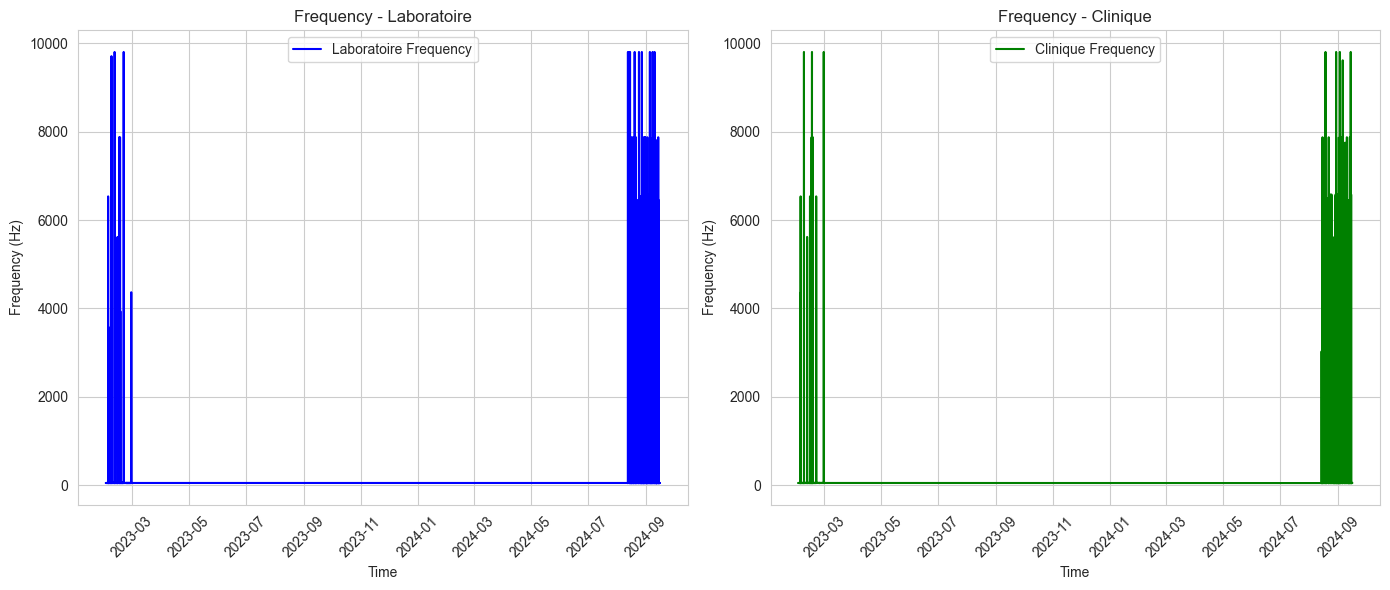

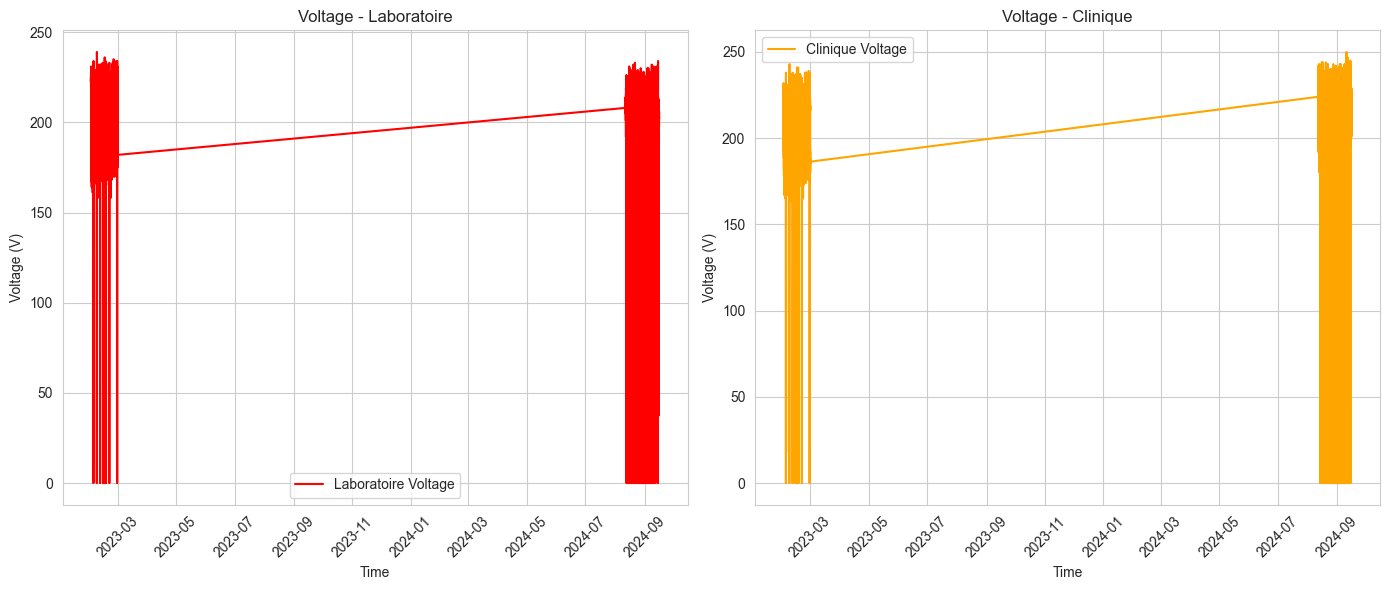

In [8]:
# Convert 'Time' column to datetime format
data['Time'] = pd.to_datetime(data['Time'])

# Plot Frequency for both facilities
plt.figure(figsize=(14, 6))

# Plot Frequency for Laboratoire
plt.subplot(1, 2, 1)
plt.plot(data['Time'], data[freq_a], label='Laboratoire Frequency', color='blue')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Frequency - Laboratoire')
plt.xticks(rotation=45)
plt.legend()

# Plot Frequency for Clinique
plt.subplot(1, 2, 2)
plt.plot(data['Time'], data[freq_b], label='Clinique Frequency', color='green')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Frequency - Clinique')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# Plot Voltage for both facilities
plt.figure(figsize=(14, 6))

# Plot Voltage for Laboratoire
plt.subplot(1, 2, 1)
plt.plot(data['Time'], data[volt_a], label='Laboratoire Voltage', color='red')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage - Laboratoire')
plt.xticks(rotation=45)
plt.legend()

# Plot Voltage for Clinique
plt.subplot(1, 2, 2)
plt.plot(data['Time'], data[volt_b], label='Clinique Voltage', color='orange')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage - Clinique')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# List of columns to calculate statistics
columns_of_interest = [
    freq_a,
    freq_b,
    volt_a,
    volt_b
]

# Calculate the statistics for each column, including mean, median, percentiles, and null counts
stats = data[columns_of_interest].agg([
    'mean',
    'median',
    lambda x: x.quantile(0.01),  # 1st percentile
    lambda x: x.quantile(0.99),  # 99th percentile
    lambda x: x.isnull().sum()/x.sum()*100  # Null counts
])

# Renaming the lambda output columns
stats.columns = columns_of_interest
stats.index = ['Mean', 'Median', '1st Percentile', '99th Percentile', 'Null Count (%)']

# Display the statistics
print(stats)

                 Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)  \
Mean                                                     72.947477            
Median                                                   50.100000            
1st Percentile                                           49.000000            
99th Percentile                                          52.100000            
Null Count (%)                                            0.000091            

                 Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)  \
Mean                                                     80.850821         
Median                                                   50.100000         
1st Percentile                                           49.000000         
99th Percentile                                          52.400000         
Null Count (%)                                            0.000027         

                 Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laborat

# 2. Training and Test Data Separation

In [10]:
# Determine the split index (60% for training)
split_index = int(len(data) * 0.6)

# Split the data into training and testing sets
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

# Display the sizes of the train and test sets
print(f'Training data size: {len(train_data)}')
print(f'Test data size: {len(test_data)}')

# Optionally, display the first few rows of each
print("Training Data Sample:")
display(train_data)

print("Test Data Sample:")
display(test_data)

Training data size: 27216
Test data size: 18144
Training Data Sample:


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON
0,2023-02-01 00:00:00,50.5,50.4,223.0,223.0,False
1,2023-02-01 00:02:00,50.6,50.5,223.0,224.0,False
2,2023-02-01 00:04:00,50.6,50.6,223.0,224.0,False
3,2023-02-01 00:06:00,50.6,50.5,224.0,225.0,False
4,2023-02-01 00:08:00,50.5,50.6,222.0,224.0,False
...,...,...,...,...,...,...
27211,2024-08-21 05:02:00,49.8,49.9,213.0,233.0,False
27212,2024-08-21 05:04:00,49.9,50.0,211.0,233.0,False
27213,2024-08-21 05:06:00,49.8,49.8,214.0,233.0,False
27214,2024-08-21 05:08:00,49.7,49.7,211.0,232.0,False


Test Data Sample:


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON
27216,2024-08-21 05:12:00,50.3,50.2,213.0,233.0,False
27217,2024-08-21 05:14:00,50.1,50.0,213.0,233.0,False
27218,2024-08-21 05:16:00,50.1,50.0,210.0,224.0,False
27219,2024-08-21 05:18:00,50.0,50.1,213.0,225.0,False
27220,2024-08-21 05:20:00,49.6,49.6,212.0,231.0,False
...,...,...,...,...,...,...
45355,2024-09-09 09:50:00,49.6,49.5,194.0,196.0,False
45356,2024-09-09 09:52:00,49.5,49.5,197.0,197.0,False
45357,2024-09-09 09:54:00,49.7,49.6,196.0,195.0,False
45358,2024-09-09 09:56:00,49.3,49.3,196.0,193.0,False


# 3. Voltage and Frequency Only 

#### *3.1. Baseline Model on the Voltage and Frequency only*

-> Choosing only the most from the train set

In [11]:
train_data_base = train_data.copy()
test_data_base = test_data.copy()

In [12]:
train_data_base['prediction'] = (train_data_base['Generator_ON'].mean()) > 0.5
test_data_base['prediction'] = (train_data_base['Generator_ON'].mean()) > 0.5

display('Train data for baseline:')
display(train_data_base['prediction'])

display('Test data for baseline:')
display(test_data_base['prediction'])

'Train data for baseline:'

0        False
1        False
2        False
3        False
4        False
         ...  
27211    False
27212    False
27213    False
27214    False
27215    False
Name: prediction, Length: 27216, dtype: bool

'Test data for baseline:'

27216    False
27217    False
27218    False
27219    False
27220    False
         ...  
45355    False
45356    False
45357    False
45358    False
45359    False
Name: prediction, Length: 18144, dtype: bool

Assessing the model:

In [13]:
# TRAIN DATA EVALUATION
metrics = evaluate_model_performance(train_data_base)

Accuracy of model: 0.8528439153439153
Confusion Matrix:
[[23211     0]
 [ 4005     0]]
Precision of model: 0.0
Recall of model: 0.0


In [14]:
# TEST DATA EVALUATION
metrics = evaluate_model_performance(test_data_base)

Accuracy of model: 0.8166887125220459
Confusion Matrix:
[[14818     0]
 [ 3326     0]]
Precision of model: 0.0
Recall of model: 0.0


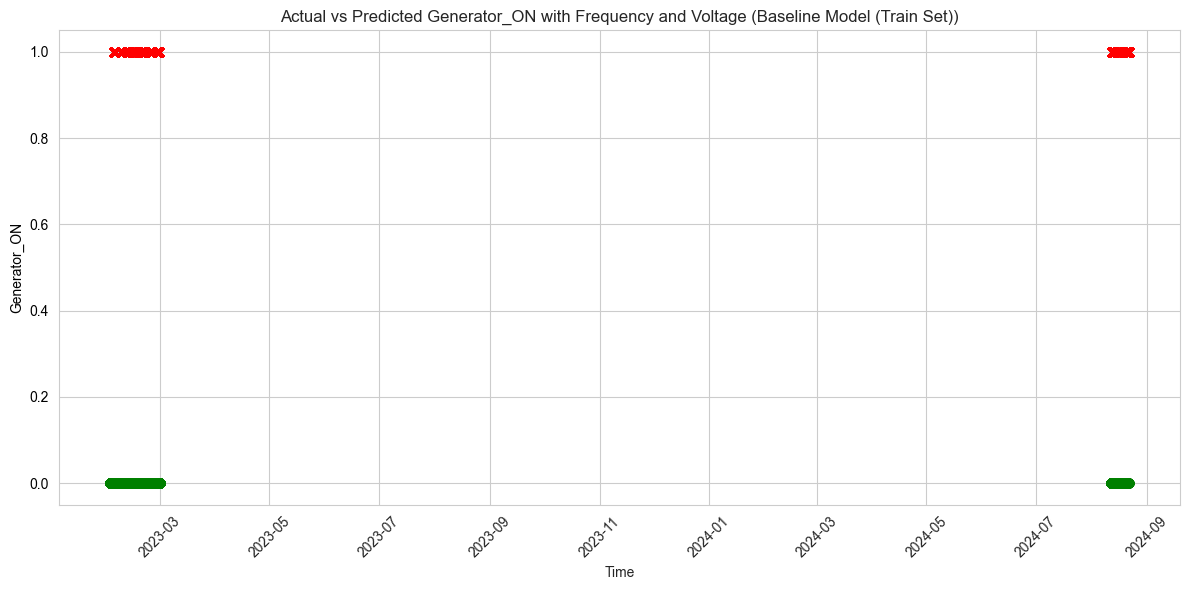

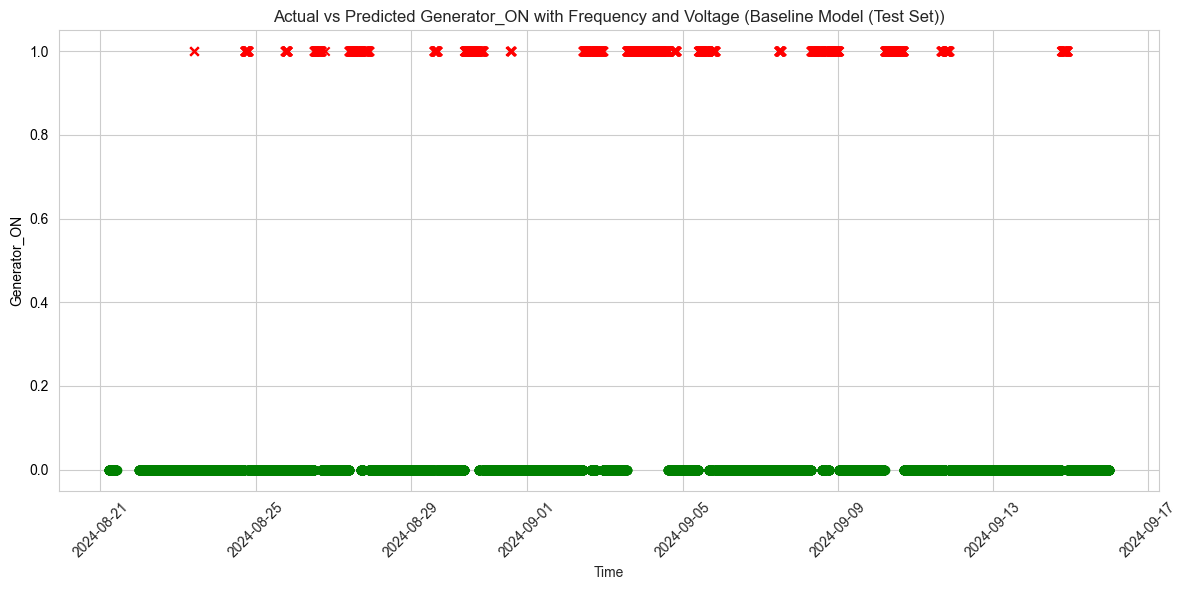

In [15]:
# For Baseline Model without voltage
plot_predictions_vs_actuals(train_data_base, model_name="Baseline Model (Train Set)", 
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_base, model_name="Baseline Model (Test Set)",  
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

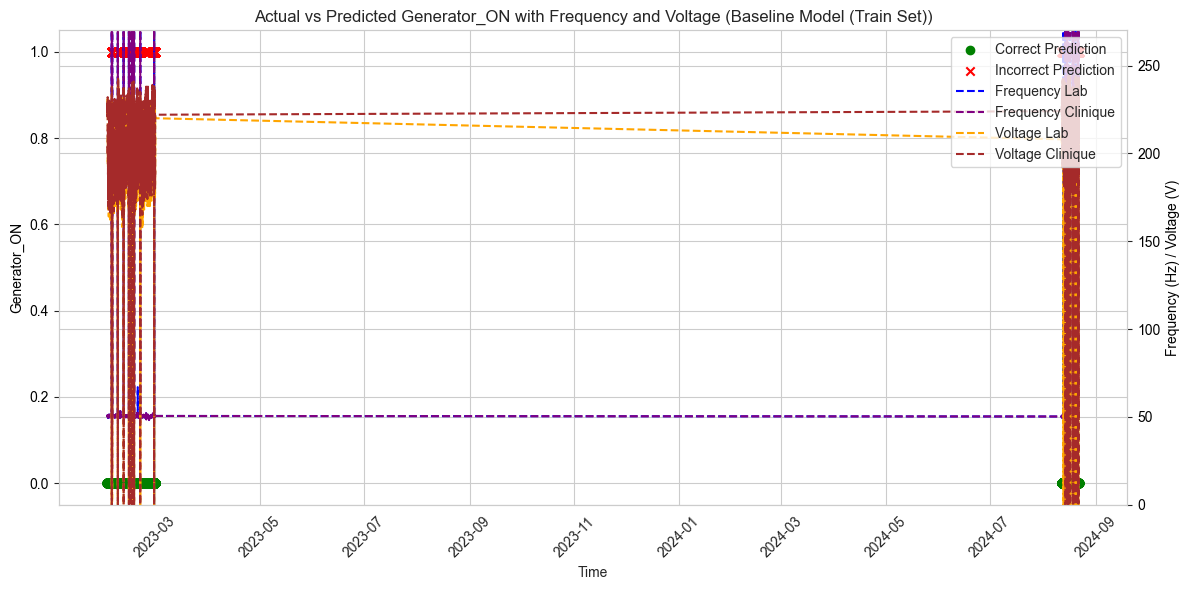

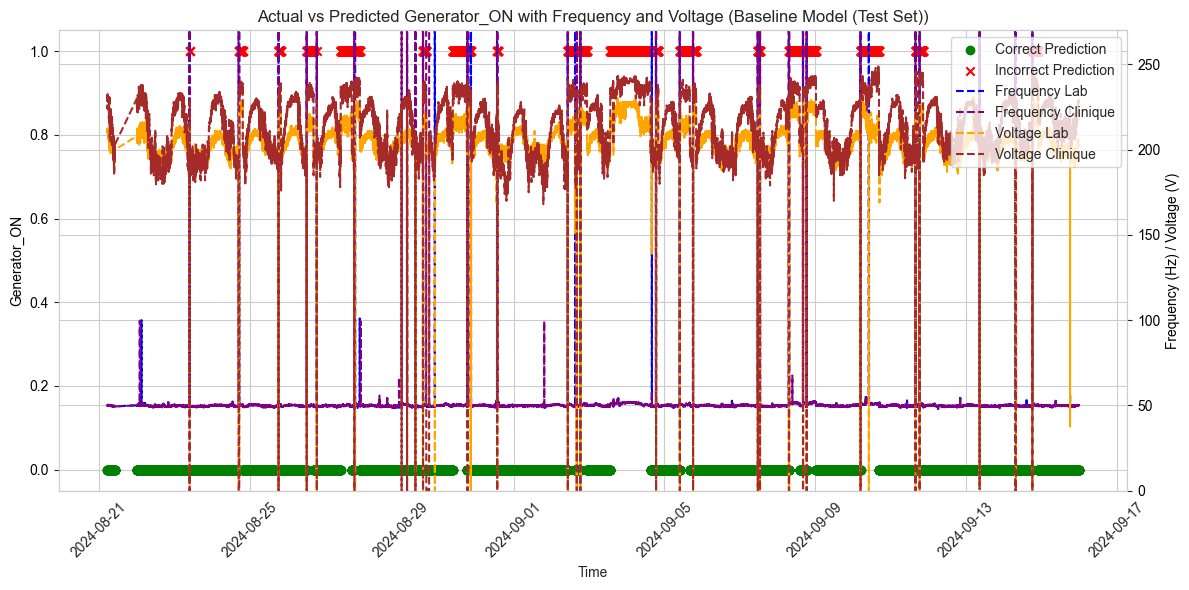

In [16]:
# For Baseline Model without voltage
plot_predictions_vs_actuals(train_data_base, model_name="Baseline Model (Train Set)",  
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
plot_predictions_vs_actuals(test_data_base, model_name="Baseline Model (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)

#### *3.2. Logistic Regression on the Voltage and Frequency only*

In [17]:
# Step 1: Create copies of the original data
train_data_mean_lg = train_data.copy()
test_data_mean_lg = test_data.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_mean_lg, test_data_mean_lg = calculate_mean_flags(train_data_mean_lg, test_data_mean_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_lg[feature_columns]
y_train = train_data_mean_lg['Generator_ON']

X_test = test_data_mean_lg[feature_columns]
y_test = test_data_mean_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_lg['prediction_value'] = reg.predict(X_train)
test_data_mean_lg['prediction_value'] = reg.predict(X_test)

# Optional: Convert predictions to binary form for classification (e.g., threshold at 0.5)
train_data_mean_lg['prediction'] = (train_data_mean_lg['prediction_value'] >= 0.5).astype(int)
test_data_mean_lg['prediction'] = (test_data_mean_lg['prediction_value'] >= 0.5).astype(int)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_mean_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_mean_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Train Accuracy: 0.85
Test Accuracy: 0.82


Evaluating the train set - Baseline Logistic Regression:

In [18]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.8515579071134627
Confusion Matrix:
[[23172    39]
 [ 4001     4]]
Precision: 0.09302325581395349
Recall: 0.0009987515605493133
Train data prediction distribution:
prediction
0    27173
1       43
Name: count, dtype: int64


Evaluating the test set - Baseline Logistic Regression:

In [19]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.8212632275132276
Confusion Matrix:
[[14788    30]
 [ 3213   113]]
Precision: 0.7902097902097902
Recall: 0.03397474443776308
Test data prediction distribution:
prediction
0    18001
1      143
Name: count, dtype: int64


#### *3.3. Random Forrest on the Voltage and Frequency only*

In [20]:
# Step 1: Create copies of the original data
train_data_rf = train_data.copy()
test_data_rf = test_data.copy()

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_rf[feature_columns]
y_train = train_data_rf['Generator_ON']

X_test = test_data_rf[feature_columns]
y_test = test_data_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_rf['prediction'] = clf.predict(X_train)
test_data_rf['prediction'] = clf.predict(X_test)

Evaluating the train set (Random Forrest): 

In [21]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.9971340388007055
Confusion Matrix:
[[23186    25]
 [   53  3952]]
Precision: 0.9937138546643198
Recall: 0.9867665418227216
Train data prediction distribution:
prediction
False    23239
True      3977
Name: count, dtype: int64


Evaluating the test set (Random Forrest): 

In [22]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9637345679012346
Confusion Matrix:
[[14668   150]
 [  508  2818]]
Precision: 0.9494609164420486
Recall: 0.8472639807576668
Test data prediction distribution:
prediction
False    15176
True      2968
Name: count, dtype: int64


#### *3.4. XG-Boost on the Voltage and Frequency only*

/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [09:10:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Top 20 features sorted by importance (XGBoost):


,Feature,Importance
3,Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - cl...,0.800886
0,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - ...,0.110703
2,Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - la...,0.052324
1,Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - ...,0.036086


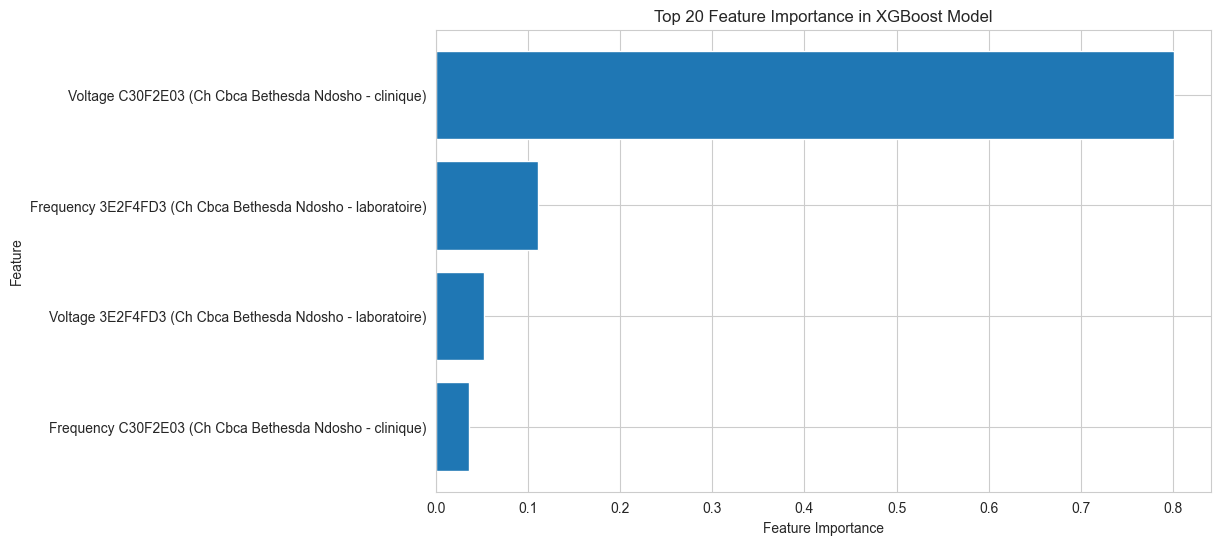

In [23]:
# Step 0: Copy rf data
train_data_boost = train_data.copy()
test_data_boost = test_data.copy()

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b
]


# Step 1: Use the same data and feature columns
X_train = train_data_boost[feature_columns]
y_train = train_data_boost['Generator_ON']

X_test = test_data_boost[feature_columns]
y_test = test_data_boost['Generator_ON']


# Step 2: Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # Evaluation metric for binary classification
    use_label_encoder=False  # Avoid unnecessary warnings
)

# Fit the model
xgb_clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_boost['prediction'] = xgb_clf.predict(X_train)
test_data_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

In [24]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 0.9932760141093474
Confusion Matrix:
[[23144    67]
 [  116  3889]]
Precision: 0.9830637007077856
Recall: 0.9710362047440699
Train data prediction distribution (XGBoost):
prediction
0    23260
1     3956
Name: count, dtype: int64


In [25]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Test Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(train_data_boost['prediction'].value_counts())

Test Set Evaluation (XGBoost):
Accuracy: 0.9664351851851852
Confusion Matrix:
[[14676   142]
 [  467  2859]]
Precision: 0.9526824391869377
Recall: 0.859591100420926
Test data prediction distribution (XGBoost):
prediction
0    23260
1     3956
Name: count, dtype: int64


# 4. Feature Generation

### 4.1. Using Mean as a Threshold

In [26]:
train_data_mean = train_data.copy()
test_data_mean = test_data.copy()

In [27]:
# Taking the mean of the dataframe
train_data_mean, test_data_mean = calculate_mean_flags(train_data_mean, test_data_mean, train_data_base, columns_to_compare)

# Display the updated data
display(train_data_mean)
display(test_data_mean)

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique
0,2023-02-01 00:00:00,50.5,50.4,223.0,223.0,False,False,False,True,True
1,2023-02-01 00:02:00,50.6,50.5,223.0,224.0,False,False,False,True,True
2,2023-02-01 00:04:00,50.6,50.6,223.0,224.0,False,False,False,True,True
3,2023-02-01 00:06:00,50.6,50.5,224.0,225.0,False,False,False,True,True
4,2023-02-01 00:08:00,50.5,50.6,222.0,224.0,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...
27211,2024-08-21 05:02:00,49.8,49.9,213.0,233.0,False,False,False,True,True
27212,2024-08-21 05:04:00,49.9,50.0,211.0,233.0,False,False,False,True,True
27213,2024-08-21 05:06:00,49.8,49.8,214.0,233.0,False,False,False,True,True
27214,2024-08-21 05:08:00,49.7,49.7,211.0,232.0,False,False,False,True,True


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique
27216,2024-08-21 05:12:00,50.3,50.2,213.0,233.0,False,False,False,True,True
27217,2024-08-21 05:14:00,50.1,50.0,213.0,233.0,False,False,False,True,True
27218,2024-08-21 05:16:00,50.1,50.0,210.0,224.0,False,False,False,True,True
27219,2024-08-21 05:18:00,50.0,50.1,213.0,225.0,False,False,False,True,True
27220,2024-08-21 05:20:00,49.6,49.6,212.0,231.0,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...
45355,2024-09-09 09:50:00,49.6,49.5,194.0,196.0,False,False,False,False,False
45356,2024-09-09 09:52:00,49.5,49.5,197.0,197.0,False,False,False,False,False
45357,2024-09-09 09:54:00,49.7,49.6,196.0,195.0,False,False,False,False,False
45358,2024-09-09 09:56:00,49.3,49.3,196.0,193.0,False,False,False,False,False


#### 4.1.1. Using Mean as a Threshold - Custom Prediction

In [28]:
# Define custom prediction logic
def custom_prediction(row):
    # Example: Set prediction to True if either clinic or lab has higher frequency and voltage
    if (row['higher_freq_lab'] or row['higher_volt_lab']) and (row['higher_freq_clinique'] or row['higher_volt_clinique']):
        return True
    else:
        return False

# Apply custom prediction logic
train_data_mean['prediction'] = train_data_mean.apply(custom_prediction, axis=1)
test_data_mean['prediction'] = test_data_mean.apply(custom_prediction, axis=1)

# Show prediction:
display('Train data for baseline:')
display(train_data_mean['prediction'].value_counts())

display('Test data for baseline:')
display(test_data_mean['prediction'].value_counts())

'Train data for baseline:'

prediction
False    13723
True     13493
Name: count, dtype: int64

'Test data for baseline:'

prediction
False    9536
True     8608
Name: count, dtype: int64

Assessing the mean model: 

In [29]:
metrics = evaluate_model_performance(train_data_mean)

Accuracy of model: 0.6511610817166372
Confusion Matrix:
[[13720  9491]
 [    3  4002]]
Precision of model: 0.29659823612243386
Recall of model: 0.9992509363295881


In [30]:
metrics = evaluate_model_performance(test_data_mean)

Accuracy of model: 0.7084435626102292
Confusion Matrix:
[[9532 5286]
 [   4 3322]]
Precision of model: 0.38592007434944237
Recall of model: 0.9987973541791942


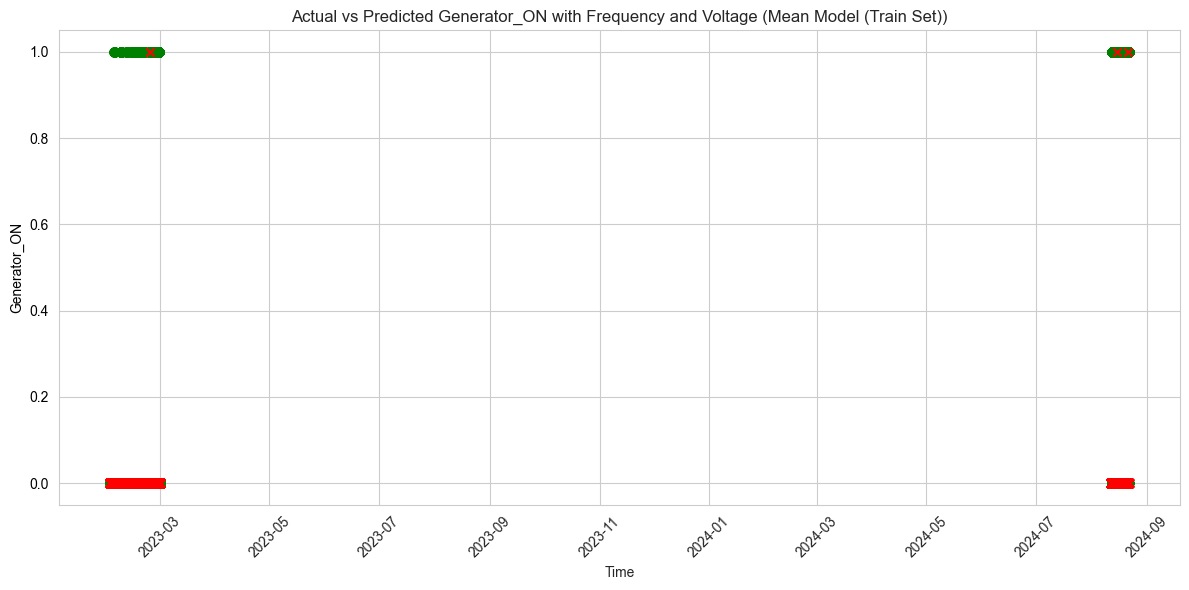

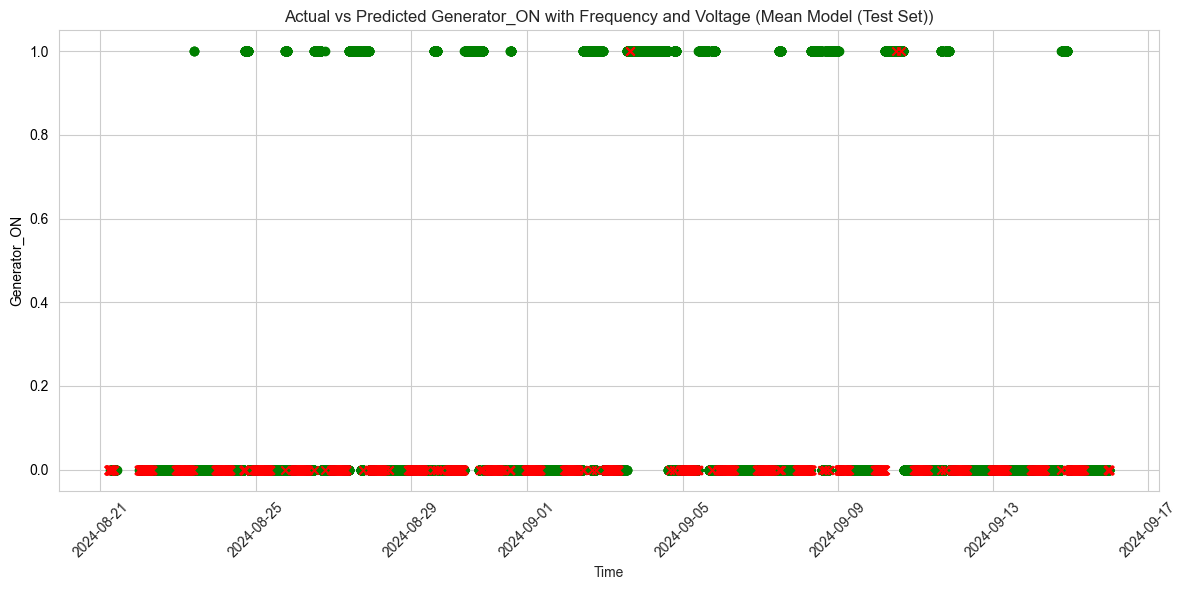

In [31]:
# For Mean Model without frequency
plot_predictions_vs_actuals(train_data_mean, model_name="Mean Model (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean, model_name="Mean Model (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

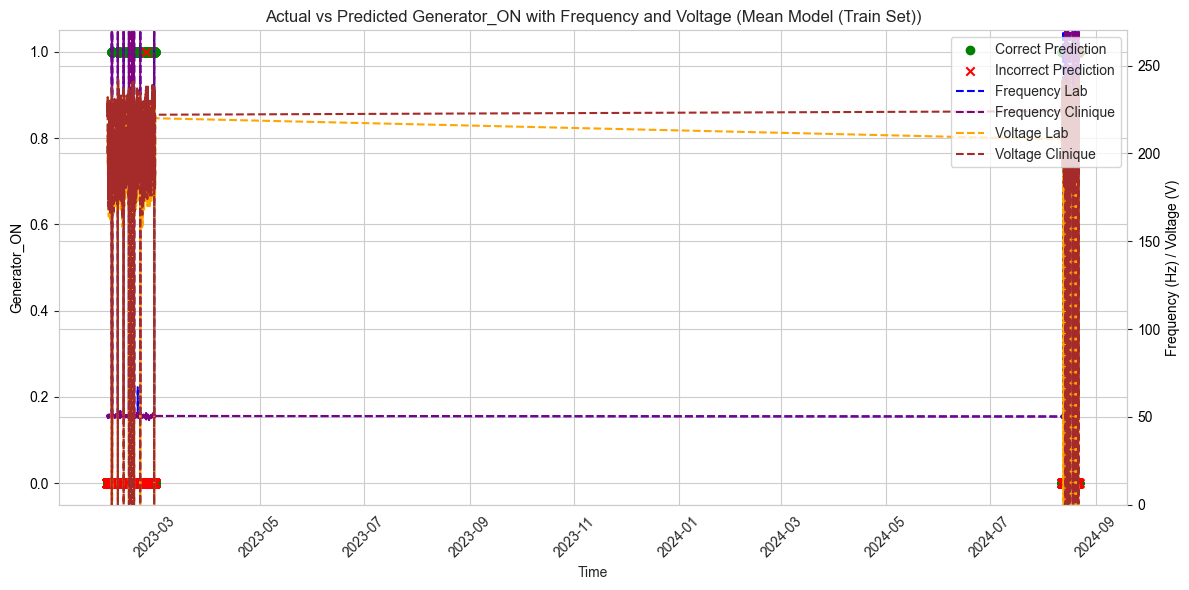

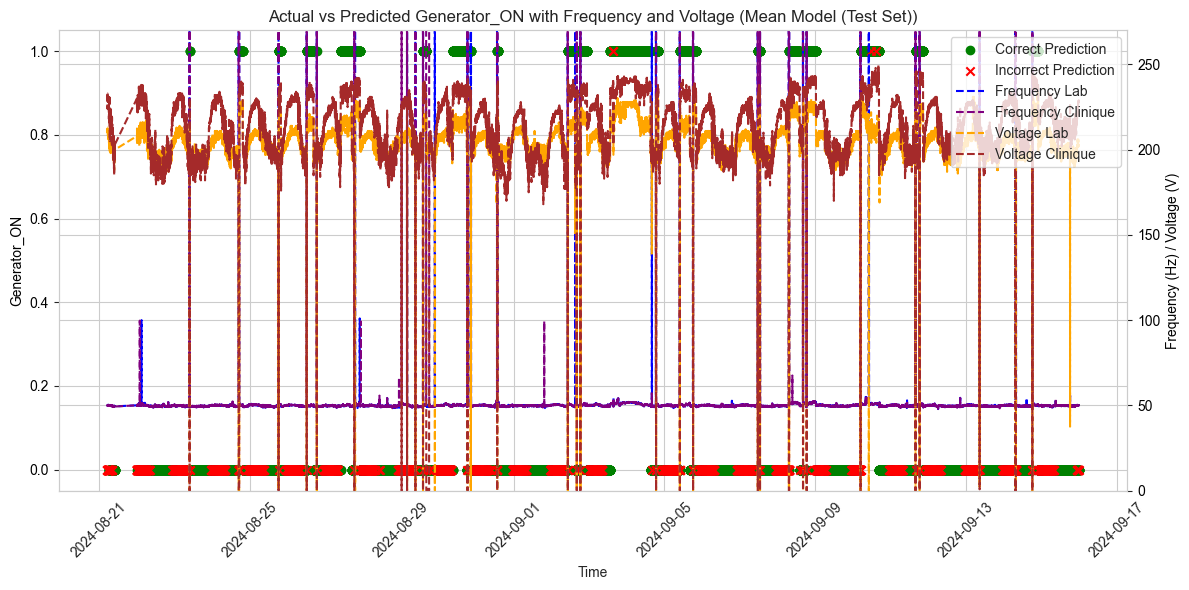

In [32]:
# For Mean Model without frequency
plot_predictions_vs_actuals(train_data_mean, model_name="Mean Model (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
plot_predictions_vs_actuals(test_data_mean, model_name="Mean Model (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)

#### 4.1.2. Using Mean as a Threshold - Logistic Regression

In [33]:
# Step 1: Create copies of the original data
train_data_mean_lg = train_data.copy()
test_data_mean_lg = test_data.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_mean_lg, test_data_mean_lg = calculate_mean_flags(train_data_mean_lg, test_data_mean_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_lg[feature_columns]
y_train = train_data_mean_lg['Generator_ON']

X_test = test_data_mean_lg[feature_columns]
y_test = test_data_mean_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_lg['prediction_value'] = reg.predict(X_train)
test_data_mean_lg['prediction_value'] = reg.predict(X_test)

# Optional: Convert predictions to binary form for classification (e.g., threshold at 0.5)
train_data_mean_lg['prediction'] = (train_data_mean_lg['prediction_value'] >= 0.5).astype(int)
test_data_mean_lg['prediction'] = (test_data_mean_lg['prediction_value'] >= 0.5).astype(int)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_mean_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_mean_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Train Accuracy: 0.89
Test Accuracy: 0.91


Evaluating the train set (Logistic Regression): 

In [34]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.8907260435038212
Confusion Matrix:
[[23130    81]
 [ 2893  1112]]
Precision: 0.9321039396479464
Recall: 0.2776529338327091
Train data prediction distribution:
prediction
0    26023
1     1193
Name: count, dtype: int64


Evaluating the test set (Logistic Regression): 

In [35]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9118165784832452
Confusion Matrix:
[[14721    97]
 [ 1503  1823]]
Precision: 0.9494791666666667
Recall: 0.5481058328322309
Test data prediction distribution:
prediction
0    16224
1     1920
Name: count, dtype: int64


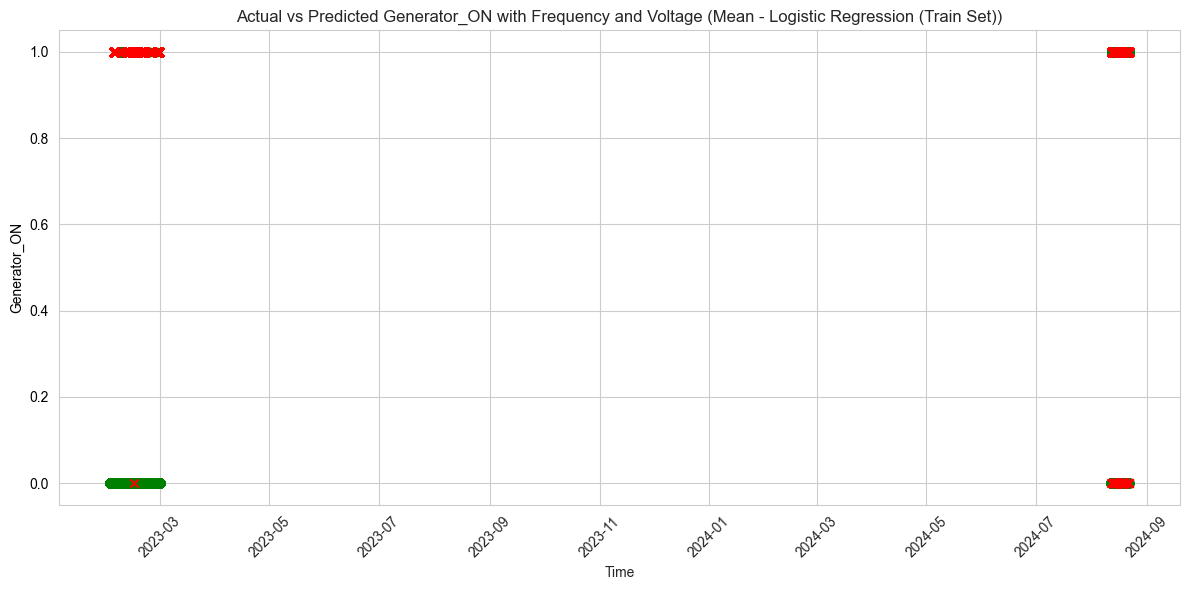

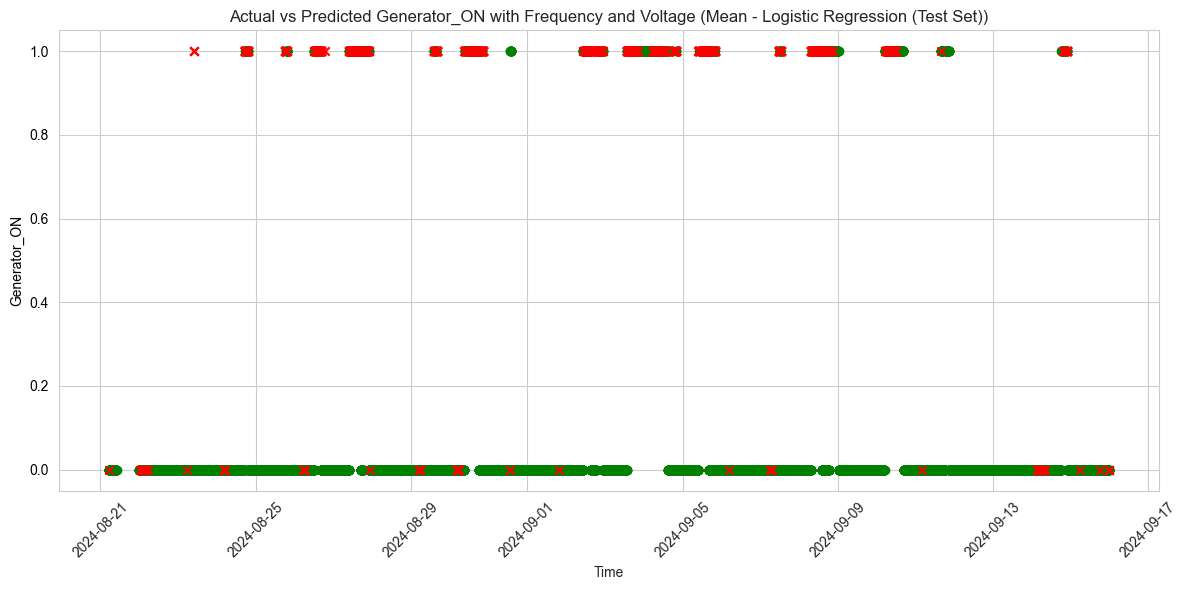

In [36]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

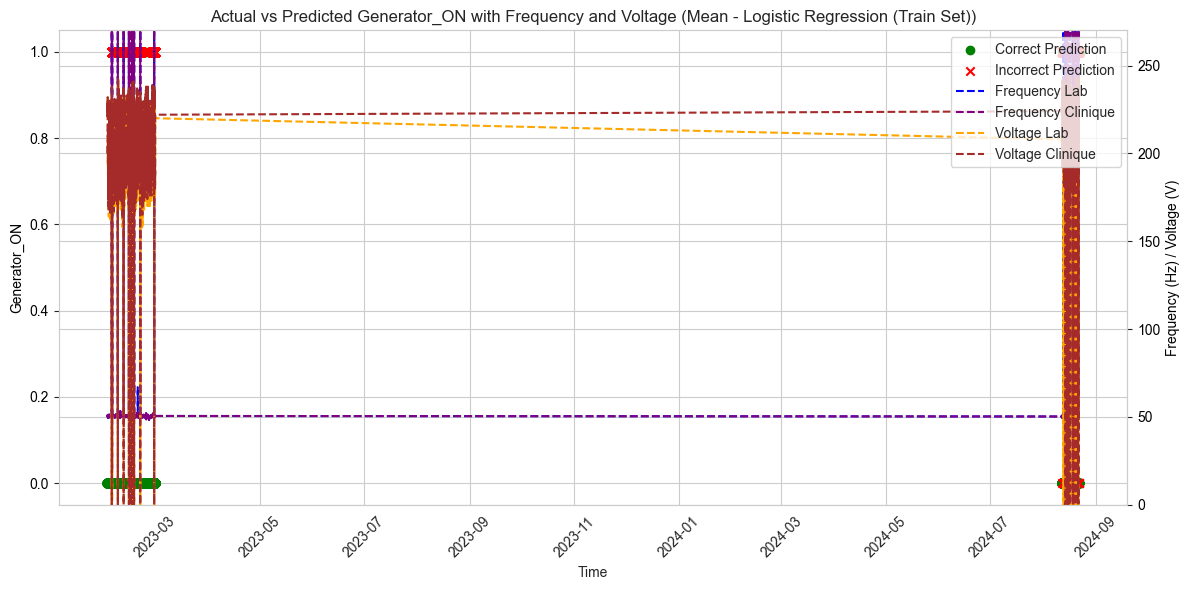

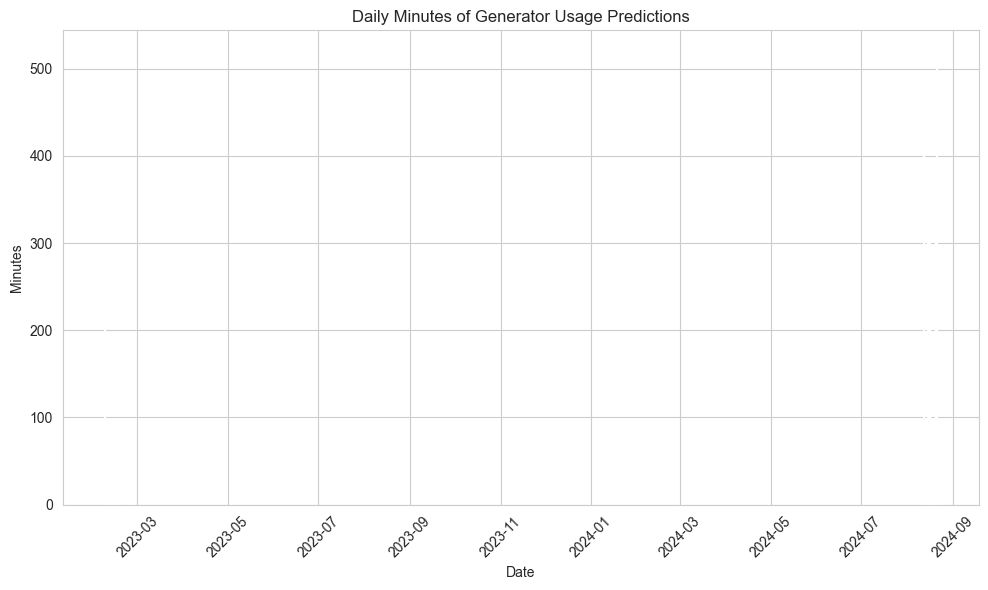

,Date,Count,Minutes,Hours
0,2023-02-07,108,216,3.600000
1,2023-02-14,1,2,0.033333
2,2023-02-15,6,12,0.200000
3,2023-02-16,4,8,0.133333
4,2023-02-23,1,2,0.033333
5,2023-02-27,1,2,0.033333
6,2024-08-12,206,412,6.866667
7,2024-08-13,34,68,1.133333
8,2024-08-14,16,32,0.533333
9,2024-08-15,182,364,6.066667


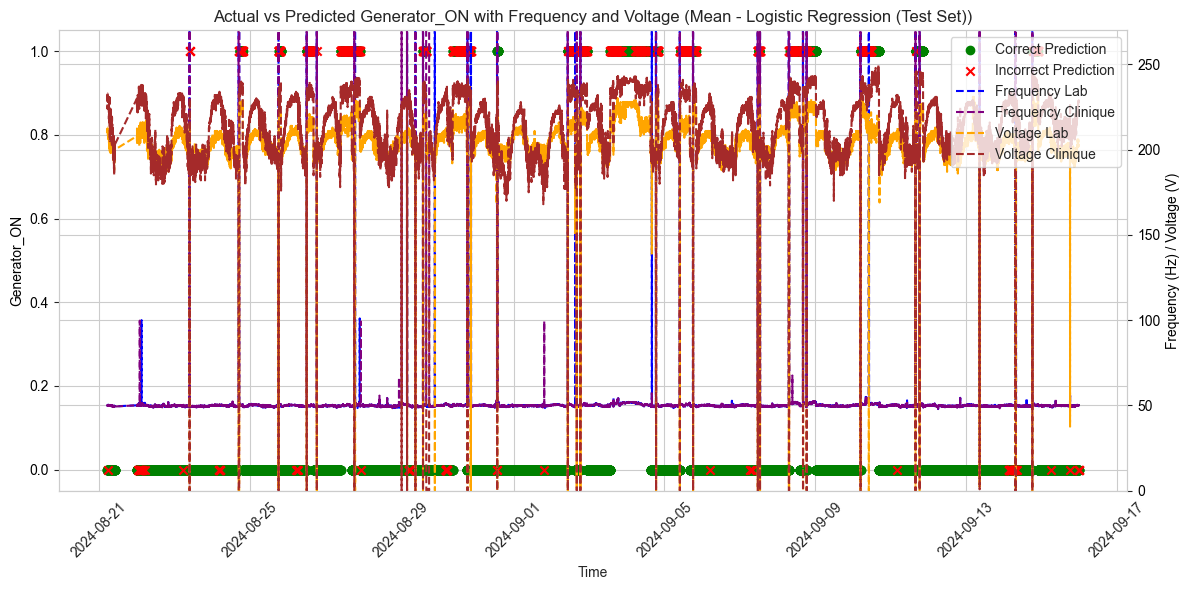

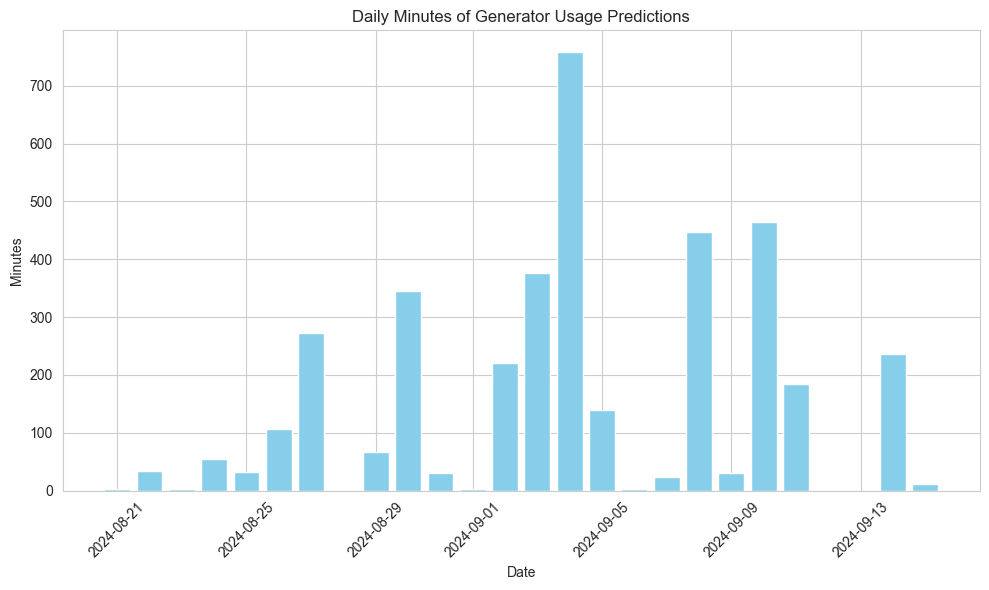

,Date,Count,Minutes,Hours
0,2024-08-21,1,2,0.033333
1,2024-08-22,17,34,0.566667
2,2024-08-23,1,2,0.033333
3,2024-08-24,27,54,0.900000
4,2024-08-25,16,32,0.533333
5,2024-08-26,53,106,1.766667
6,2024-08-27,136,272,4.533333
7,2024-08-29,33,66,1.100000
8,2024-08-30,173,346,5.766667
9,2024-08-31,15,30,0.500000


In [37]:
# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_lg_daily_count = plot_true_predictions_histogram(train_data_mean_lg)
display(train_data_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_lg_daily_count = plot_true_predictions_histogram(test_data_mean_lg)
display(test_data_lg_daily_count)

#### 4.1.3. Using Mean as a Threshold - Random Forrest

In [38]:
# Step 1: Create copies of the original data
train_data_mean_rf = train_data.copy()
test_data_mean_rf = test_data.copy()

# Taking the mean of the dataframe
train_data_mean_rf, test_data_mean_rf = calculate_mean_flags(train_data_mean_rf, test_data_mean_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_rf[feature_columns]
y_train = train_data_mean_rf['Generator_ON']

X_test = test_data_mean_rf[feature_columns]
y_test = test_data_mean_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_rf['prediction'] = clf.predict(X_train)
test_data_mean_rf['prediction'] = clf.predict(X_test)

Evaluating the train set (Random Forrest): 

In [39]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.9971340388007055
Confusion Matrix:
[[23189    22]
 [   56  3949]]
Precision: 0.9944598337950139
Recall: 0.9860174781523097
Train data prediction distribution:
prediction
False    23245
True      3971
Name: count, dtype: int64


Evaluating the test set (Random Forrest): 

In [40]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9660493827160493
Confusion Matrix:
[[14687   131]
 [  485  2841]]
Precision: 0.9559219380888291
Recall: 0.8541791942273
Test data prediction distribution:
prediction
False    15172
True      2972
Name: count, dtype: int64


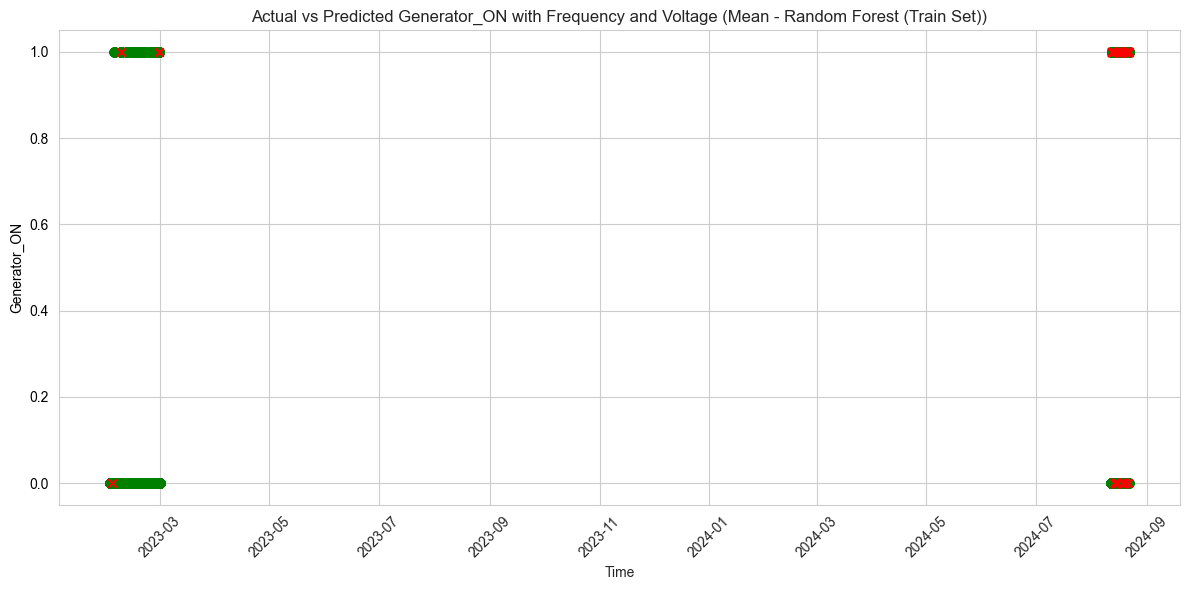

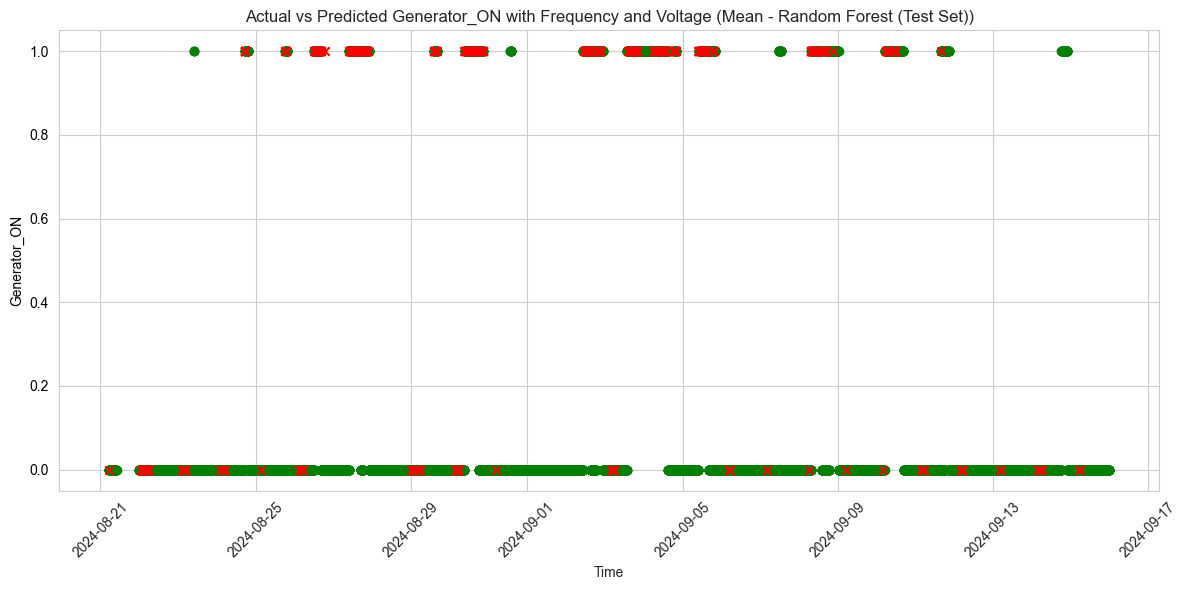

In [41]:
# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

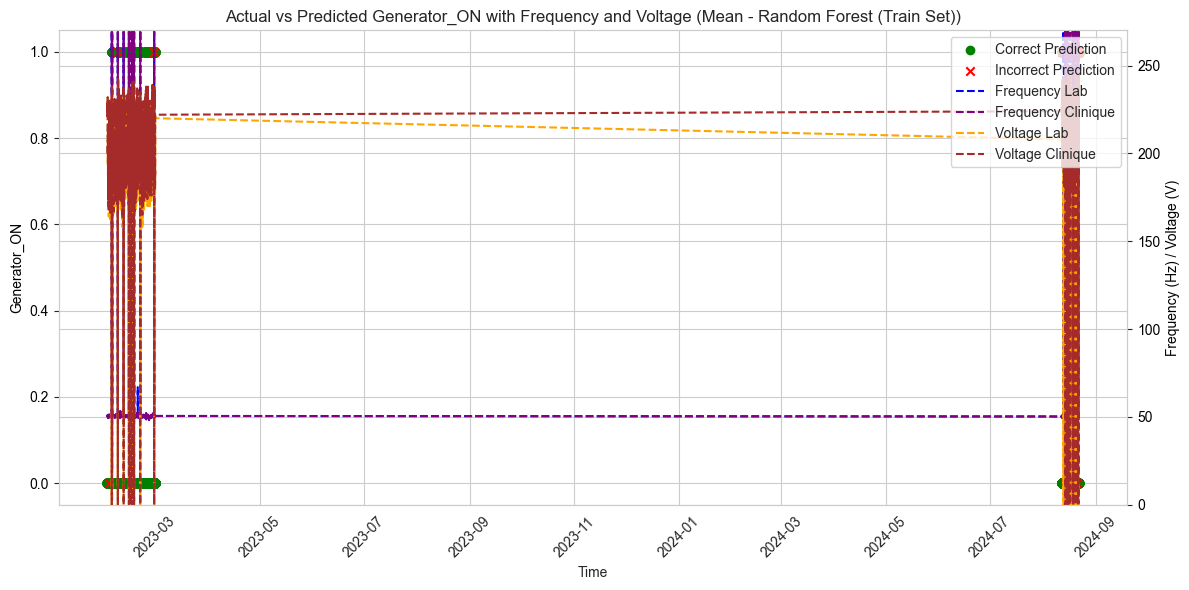

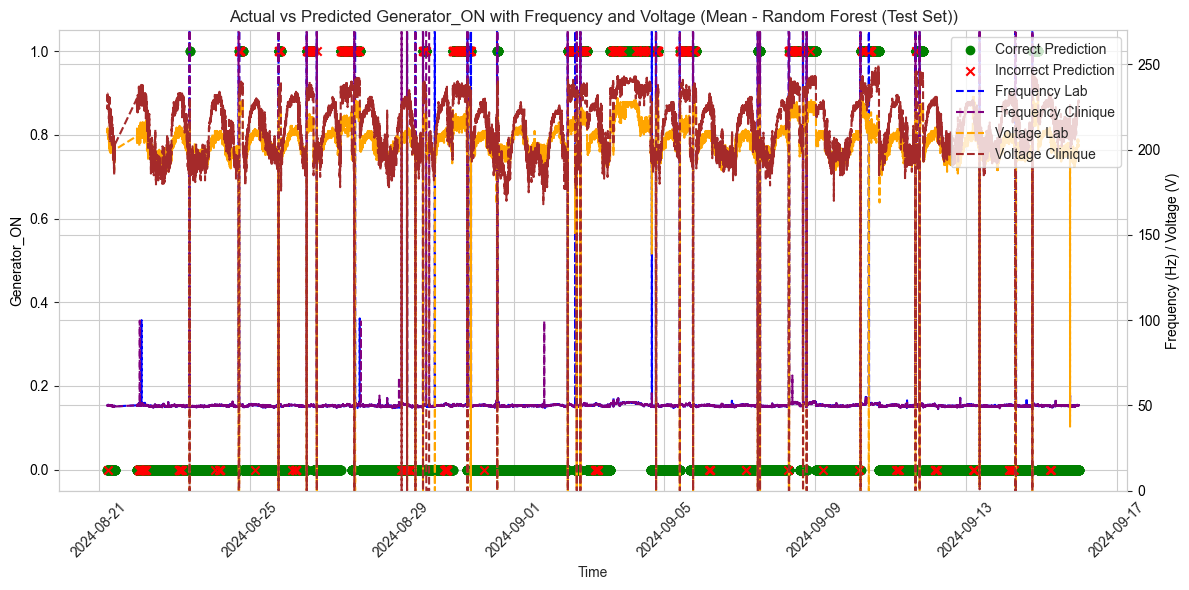

In [42]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_mean_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)

In [43]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_mean_rf)
display_generator_statistics(test_data_mean_rf)

##### PREDICTION RESULT #####
Actual Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Predicted Minutes: 3971 minutes, or 66.18 hours within 453.60 hours
Actual Minutes: 3326 minutes, or 55.43 hours within 302.40 hours
Predicted Minutes: 2972 minutes, or 49.53 hours within 302.40 hours


#### 4.1.4. Using Mean as a Threshold - XGBoost

Top 20 features sorted by importance (XGBoost):


/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [09:10:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Feature,Importance
3,Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - cl...,0.800886
0,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - ...,0.110703
2,Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - la...,0.052324
1,Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - ...,0.036086
4,higher_freq_lab,0.000000
5,higher_freq_clinique,0.000000
6,higher_volt_lab,0.000000
7,higher_volt_clinique,0.000000


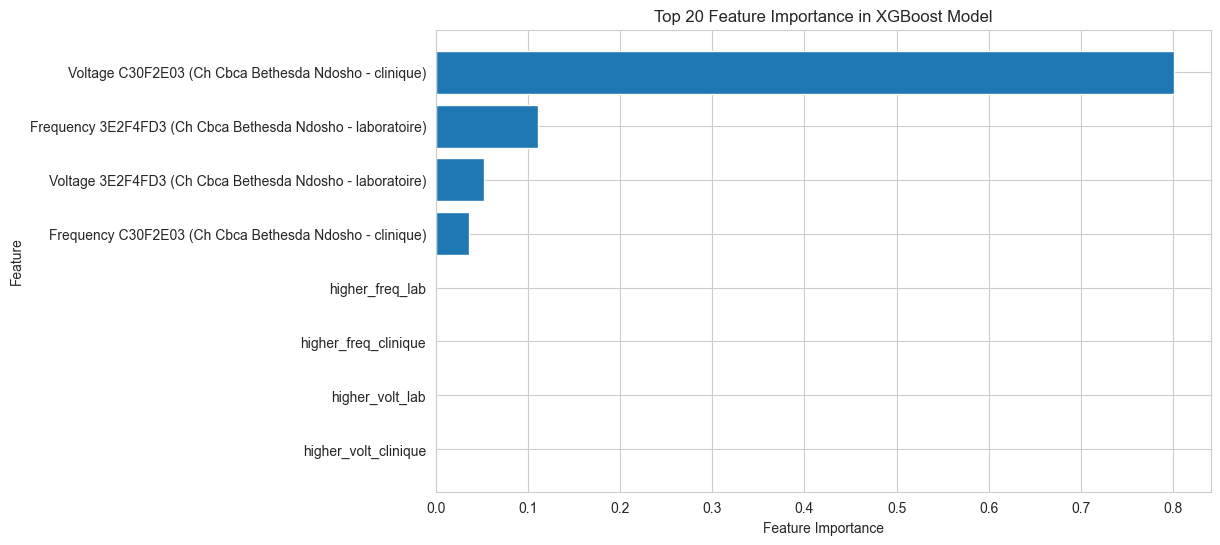

In [44]:
# Step 0: Copy rf data
train_data_mean_boost = train_data.copy()
test_data_mean_boost = test_data.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_mean_boost, test_data_mean_boost = calculate_mean_flags(train_data_mean_boost, test_data_mean_boost, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique'
]


# Step 1: Use the same data and feature columns
X_train = train_data_mean_boost[feature_columns]
y_train = train_data_mean_boost['Generator_ON']

X_test = test_data_mean_boost[feature_columns]
y_test = test_data_mean_boost['Generator_ON']


# Step 2: Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # Evaluation metric for binary classification
    use_label_encoder=False  # Avoid unnecessary warnings
)

# Fit the model
xgb_clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_boost['prediction'] = xgb_clf.predict(X_train)
test_data_mean_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

In [45]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_mean_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_mean_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 0.9932760141093474
Confusion Matrix:
[[23144    67]
 [  116  3889]]
Precision: 0.9830637007077856
Recall: 0.9710362047440699
Train data prediction distribution (XGBoost):
prediction
0    23260
1     3956
Name: count, dtype: int64


In [46]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Test Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_mean_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(train_data_mean_boost['prediction'].value_counts())

Test Set Evaluation (XGBoost):
Accuracy: 0.9664351851851852
Confusion Matrix:
[[14676   142]
 [  467  2859]]
Precision: 0.9526824391869377
Recall: 0.859591100420926
Test data prediction distribution (XGBoost):
prediction
0    23260
1     3956
Name: count, dtype: int64


In [47]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_mean_boost)
display_generator_statistics(test_data_mean_boost)

##### PREDICTION RESULT #####
Actual Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Predicted Minutes: 3956 minutes, or 65.93 hours within 453.60 hours
Actual Minutes: 3326 minutes, or 55.43 hours within 302.40 hours
Predicted Minutes: 3001 minutes, or 50.02 hours within 302.40 hours


### 4.2. Generating Time Series Feature

In [48]:
## INITIALIZATION OF CONSTANTS
# Range of reasonable frequency and voltage
high_freq_threshold = 60
low_freq_threshold = 40

high_volt_threshold = 250
low_volt_threshold = 2

voltage_delta = 10

In [49]:
train_data_ts = train_data.copy()
test_data_ts = test_data.copy()

In [50]:
## FEATURE GENERATION
# Using mean to compare
train_data_ts, test_data_ts = calculate_mean_flags(train_data_ts, test_data_ts, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
train_data_ts, test_data_ts = process_time_series_data(train_data_ts, test_data_ts, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display the processed data
display(train_data_ts)
display(test_data_ts)

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
0,2023-02-01 00:00:00,50.5,50.4,223.0,223.0,False,False,False,True,True,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
1,2023-02-01 00:02:00,50.6,50.5,223.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,2023-02-01 00:04:00,50.6,50.6,223.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
3,2023-02-01 00:06:00,50.6,50.5,224.0,225.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
4,2023-02-01 00:08:00,50.5,50.6,222.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27211,2024-08-21 05:02:00,49.8,49.9,213.0,233.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
27212,2024-08-21 05:04:00,49.9,50.0,211.0,233.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
27213,2024-08-21 05:06:00,49.8,49.8,214.0,233.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
27214,2024-08-21 05:08:00,49.7,49.7,211.0,232.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
27216,2024-08-21 05:12:00,50.3,50.2,213.0,233.0,False,False,False,True,True,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
27217,2024-08-21 05:14:00,50.1,50.0,213.0,233.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
27218,2024-08-21 05:16:00,50.1,50.0,210.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
27219,2024-08-21 05:18:00,50.0,50.1,213.0,225.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
27220,2024-08-21 05:20:00,49.6,49.6,212.0,231.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45355,2024-09-09 09:50:00,49.6,49.5,194.0,196.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45356,2024-09-09 09:52:00,49.5,49.5,197.0,197.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45357,2024-09-09 09:54:00,49.7,49.6,196.0,195.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45358,2024-09-09 09:56:00,49.3,49.3,196.0,193.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [51]:
train_data_ts.columns

Index(['Time', 'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
       'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
       'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
       'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 'Generator_ON',
       'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
       'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
       'freq_delta_negative_clinique', 'volt_delta_positive_lab',
       'volt_delta_positive_clinique', 'freq_in_range_lab',
       'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
       'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
       'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
       'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
       'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
      

#### 4.2.1. Using Mean of Voltage and Frequency as a Threshold and Time Series - Logistic Regression

Train Accuracy: 0.98
Test Accuracy: 0.97
Top 20 features sorted by absolute coefficient value:


/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Feature,Coefficient
6,higher_volt_lab,7.326136
7,higher_volt_clinique,5.879787
21,Hour_1,-5.268153
22,Hour_2,-5.215689
20,Hour_0,-4.688239
18,freq_in_range_clinique,-4.453222
19,volt_in_range_clinique,-4.390031
17,volt_in_range_lab,-4.344797
16,freq_in_range_lab,-4.344523
43,Hour_23,-4.108790


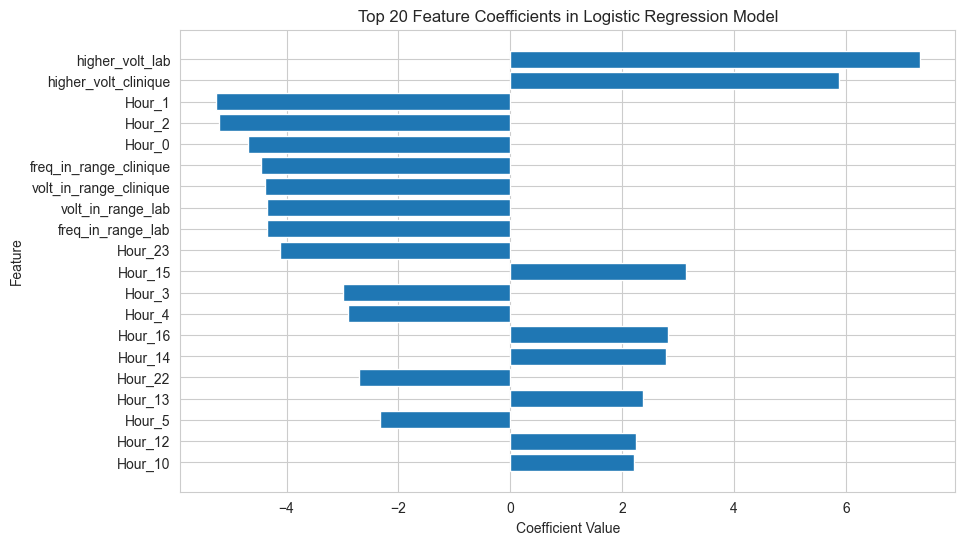

In [52]:

# Step 1: Create copies of the original data
train_data_ts_lg = train_data_ts.copy()
test_data_ts_lg = test_data_ts.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_ts_lg, test_data_ts_lg = calculate_mean_flags(train_data_ts_lg, test_data_ts_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_lg[feature_columns]
y_train = train_data_ts_lg['Generator_ON']

X_test = test_data_ts_lg[feature_columns]
y_test = test_data_ts_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Logistic Regression model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_lg['prediction'] = clf.predict(X_train)
test_data_ts_lg['prediction'] = clf.predict(X_test)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_ts_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_ts_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Step 4: Get the feature coefficients (importance in logistic regression)
coefficients = clf.coef_[0]  # Extract coefficients from the trained model

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': coefficients
})

# Sort the features by absolute value of the coefficient and keep the top 20
top_20_features = feature_importance_df.reindex(
    feature_importance_df['Coefficient'].abs().sort_values(ascending=False).index
).head(20)

# Display the top 20 most significant features
print("Top 20 features sorted by absolute coefficient value:")
display(top_20_features)

# Visualize the top 20 feature coefficients
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Coefficient'])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Top 20 Feature Coefficients in Logistic Regression Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most significant features on top
plt.show()

In [53]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.9750881834215167
Confusion Matrix:
[[22946   265]
 [  413  3592]]
Precision: 0.9312937516204304
Recall: 0.8968789013732834
Train data prediction distribution:
prediction
False    23359
True      3857
Name: count, dtype: int64


In [54]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9694113756613757
Confusion Matrix:
[[14778    40]
 [  515  2811]]
Precision: 0.9859698351455629
Recall: 0.8451593505712568
Test data prediction distribution:
prediction
False    15293
True      2851
Name: count, dtype: int64


In [55]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_lg)
display_generator_statistics(test_data_ts_lg)

##### PREDICTION RESULT #####
Actual Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Predicted Minutes: 3857 minutes, or 64.28 hours within 453.60 hours
Actual Minutes: 3326 minutes, or 55.43 hours within 302.40 hours
Predicted Minutes: 2851 minutes, or 47.52 hours within 302.40 hours


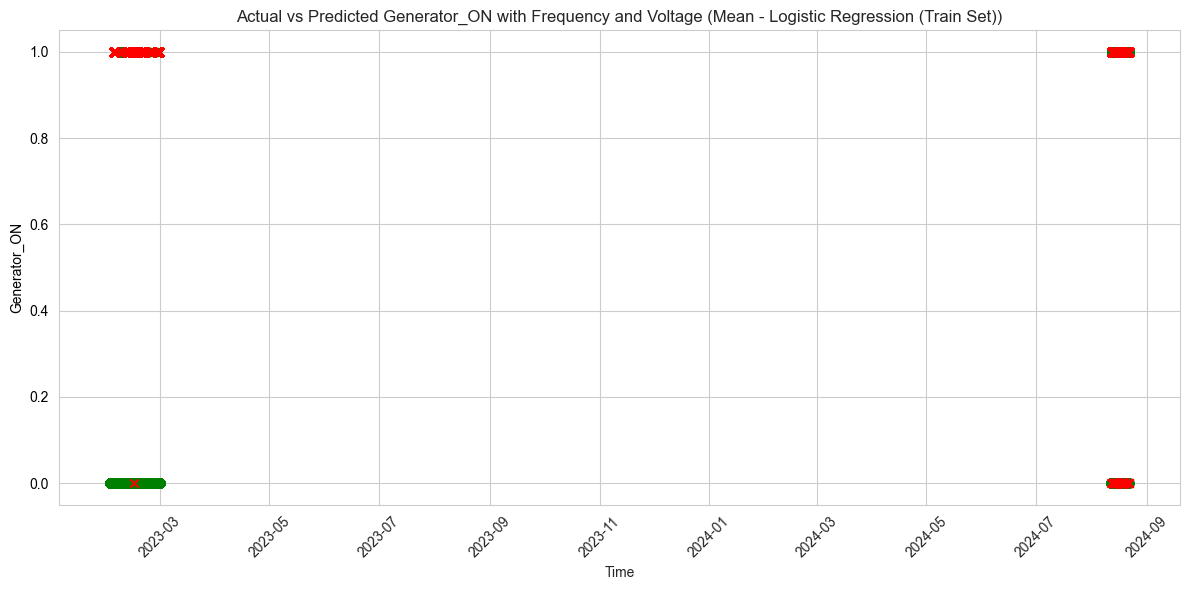

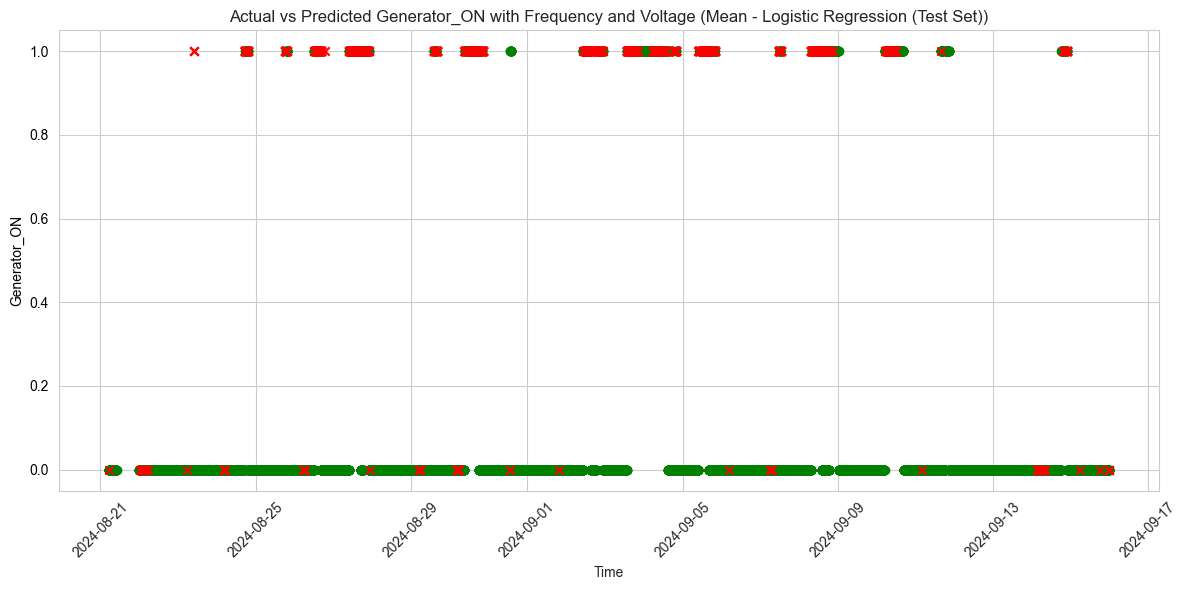

In [56]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

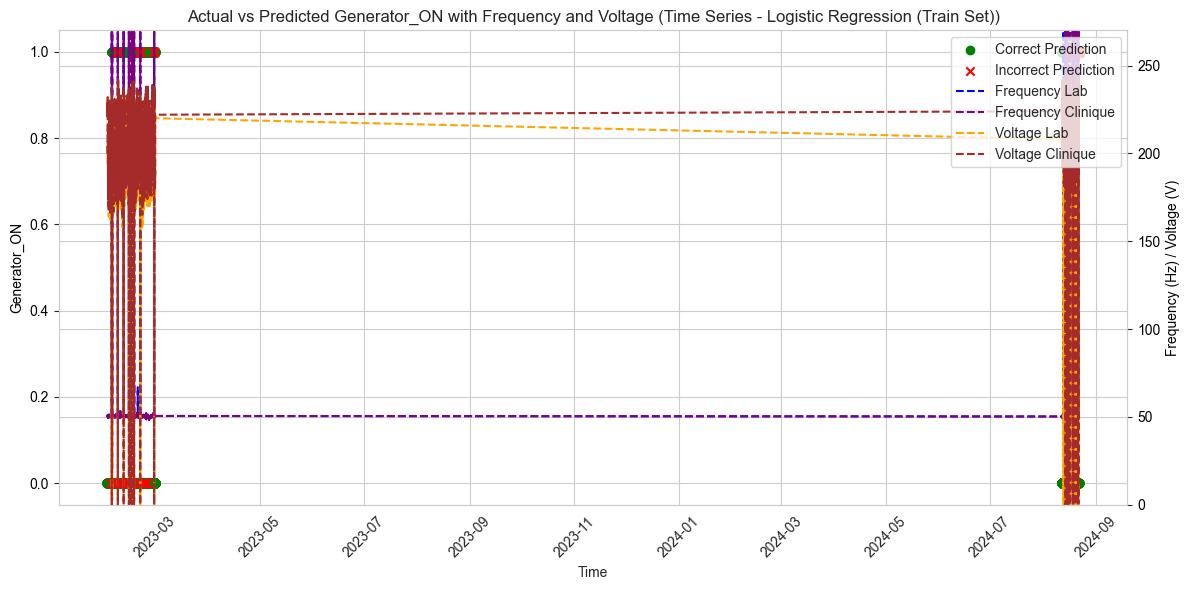

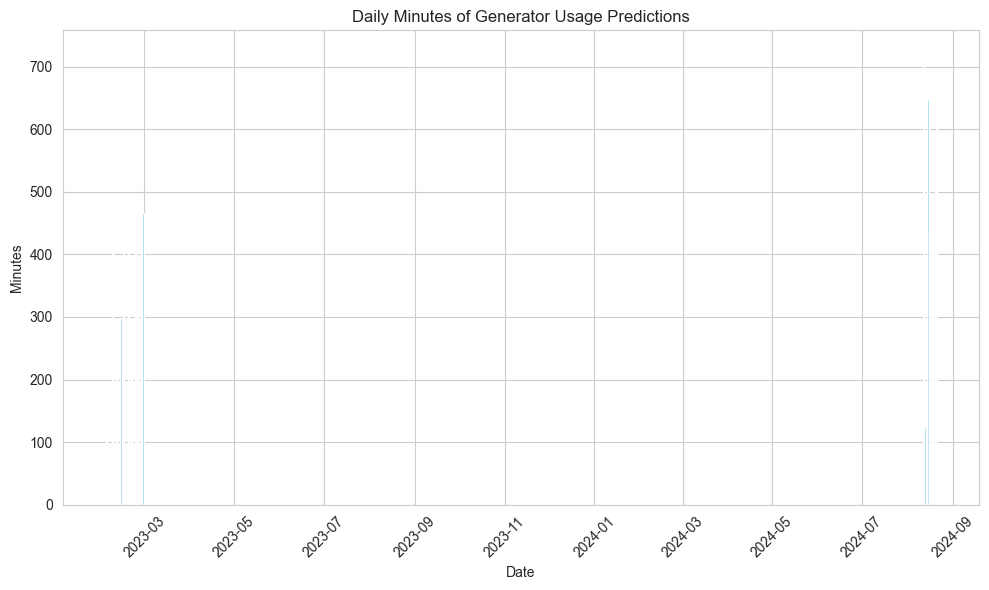

,Date,Count,Minutes,Hours
0,2023-02-02,1,2,0.033333
1,2023-02-03,76,152,2.533333
2,2023-02-06,8,16,0.266667
3,2023-02-07,207,414,6.900000
4,2023-02-08,4,8,0.133333
5,2023-02-09,1,2,0.033333
6,2023-02-10,129,258,4.300000
7,2023-02-12,4,8,0.133333
8,2023-02-13,149,298,4.966667
9,2023-02-14,2,4,0.066667


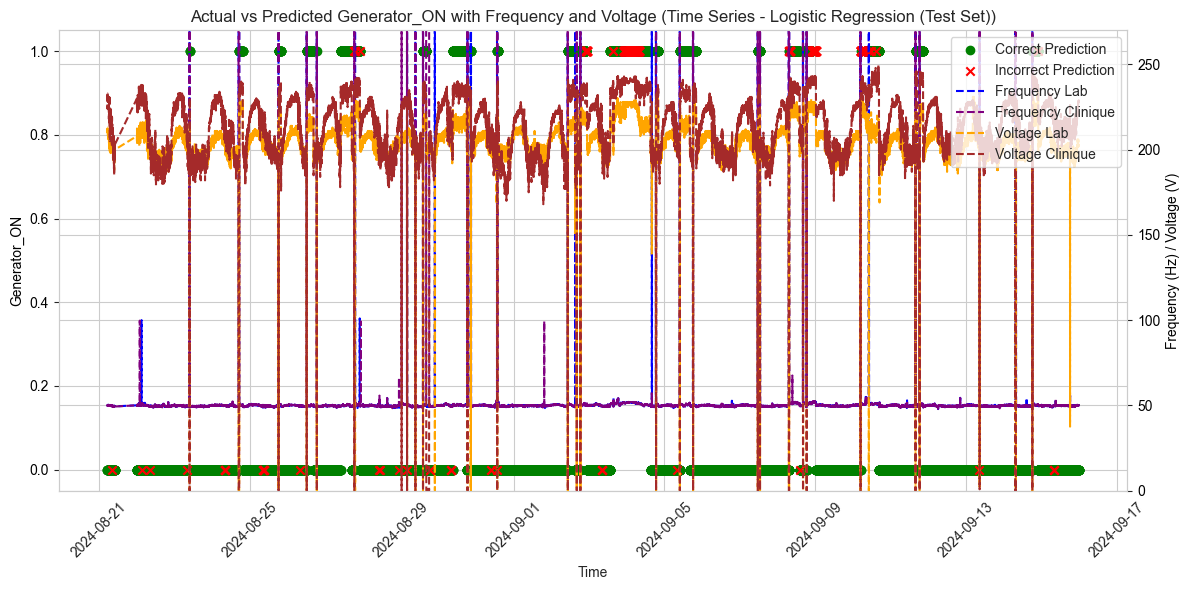

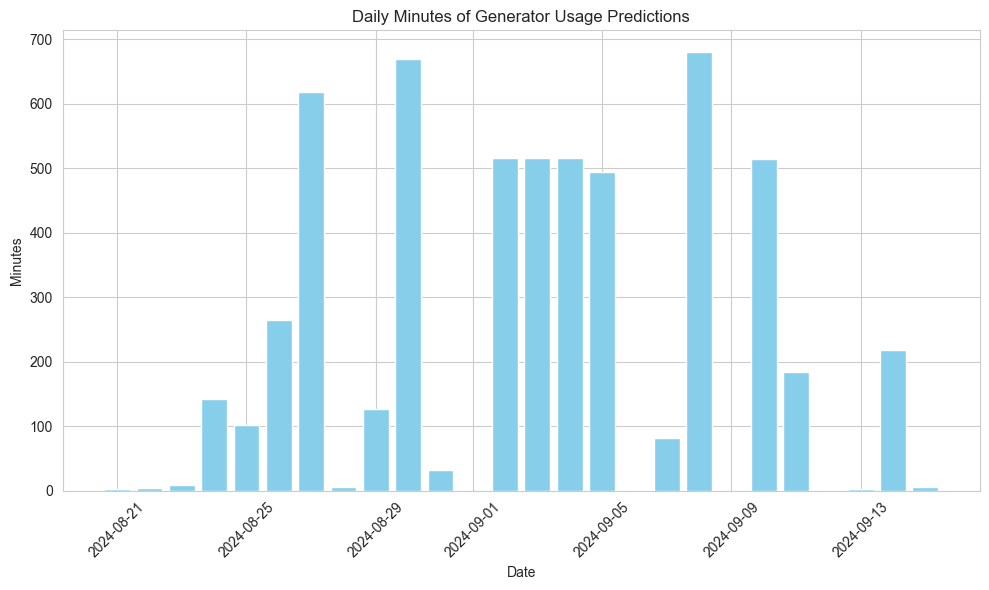

,Date,Count,Minutes,Hours
0,2024-08-21,1,2,0.033333
1,2024-08-22,2,4,0.066667
2,2024-08-23,4,8,0.133333
3,2024-08-24,71,142,2.366667
4,2024-08-25,51,102,1.700000
5,2024-08-26,132,264,4.400000
6,2024-08-27,309,618,10.300000
7,2024-08-28,3,6,0.100000
8,2024-08-29,63,126,2.100000
9,2024-08-30,335,670,11.166667


In [57]:
# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_lg, model_name="Time Series - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_lg_daily_count = plot_true_predictions_histogram(train_data_ts_lg)
display(train_data_ts_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_lg, model_name="Time Series - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_lg_daily_count = plot_true_predictions_histogram(test_data_ts_lg)
display(test_data_ts_lg_daily_count)

#### 4.2.2. Using Mean of Voltage and Frequency as a Threshold and Time Series - Random Forrest

Top 15 features sorted by importance:


,Feature,Importance
3,Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - cl...,0.419528
2,Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - la...,0.148025
0,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - ...,0.071939
1,Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - ...,0.070741
6,higher_volt_lab,0.046275
7,higher_volt_clinique,0.031487
31,Hour_11,0.018083
33,Hour_13,0.014285
34,Hour_14,0.013974
24,Hour_4,0.013622


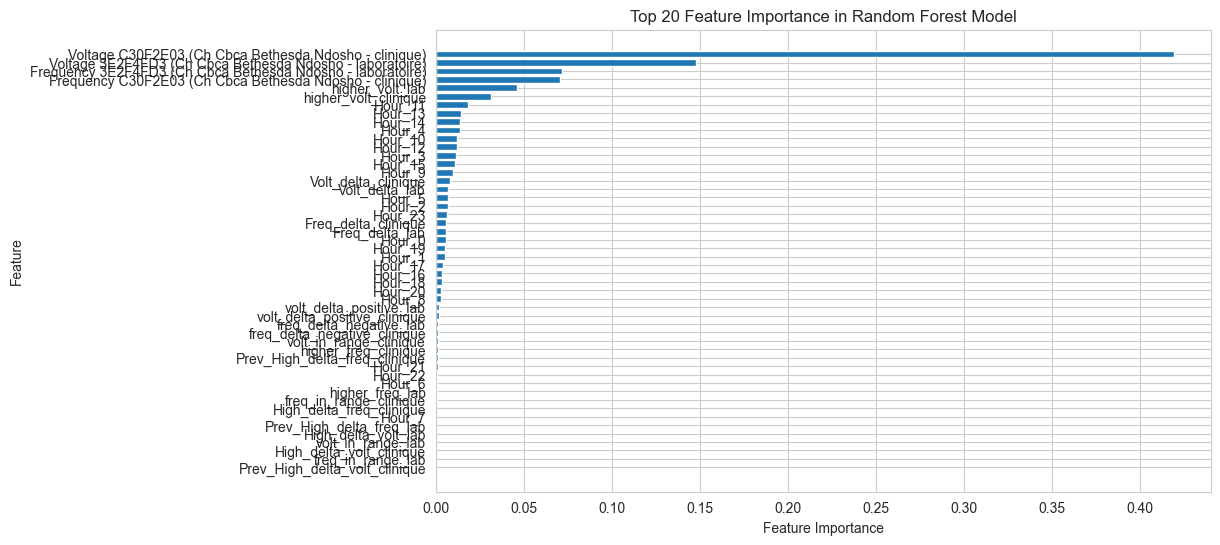

In [58]:
# Step 1: Create copies of the original data
train_data_ts_rf = train_data_ts.copy()
test_data_ts_rf = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_rf, test_data_ts_rf = calculate_mean_flags(train_data_ts_rf, test_data_ts_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_rf[feature_columns]
y_train = train_data_ts_rf['Generator_ON']

X_test = test_data_ts_rf[feature_columns]
y_test = test_data_ts_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_rf['prediction'] = clf.predict(X_train)
test_data_ts_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(50)

# Display the top 15 most important features
print("Top 15 features sorted by importance:")
display(top_15_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(top_15_features['Feature'], top_15_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

Evaluating the train and test set

In [59]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 1.0
Confusion Matrix:
[[23211     0]
 [    0  4005]]
Precision: 1.0
Recall: 1.0
Train data prediction distribution:
prediction
False    23211
True      4005
Name: count, dtype: int64


In [60]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9933862433862434
Confusion Matrix:
[[14808    10]
 [  110  3216]]
Precision: 0.9969001859888407
Recall: 0.9669272399278412
Test data prediction distribution:
prediction
False    14918
True      3226
Name: count, dtype: int64


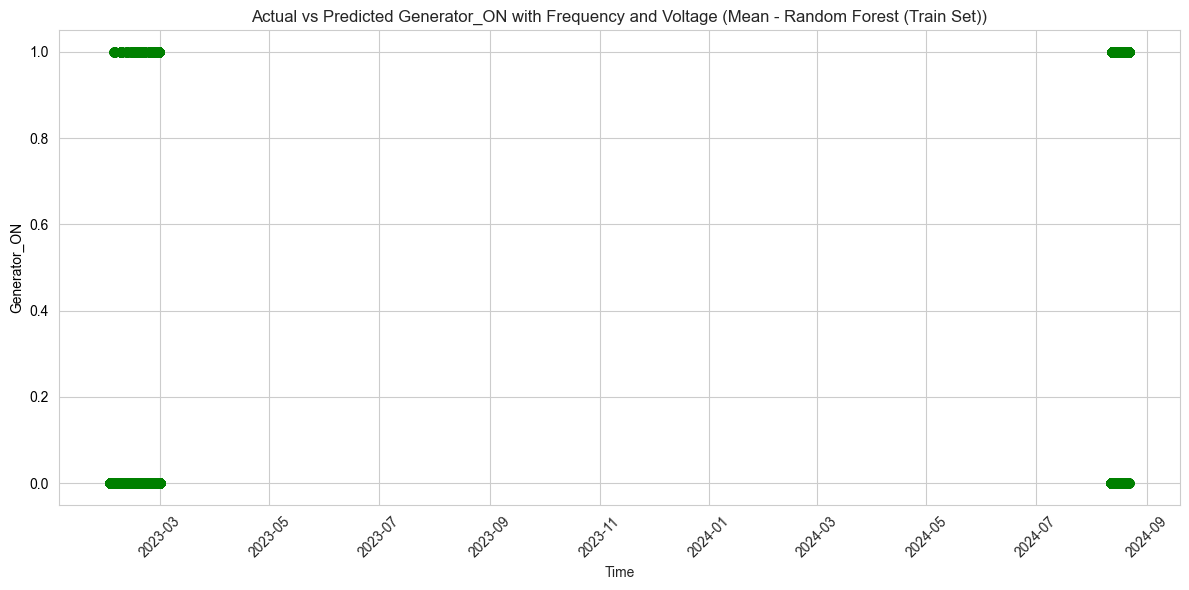

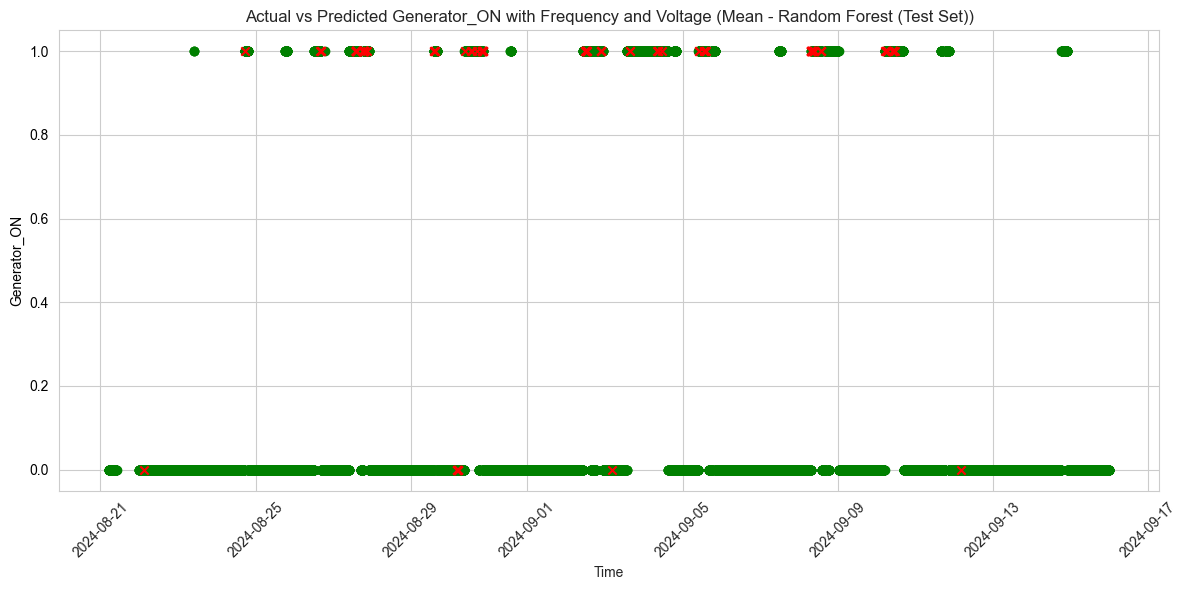

In [61]:
# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_ts_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

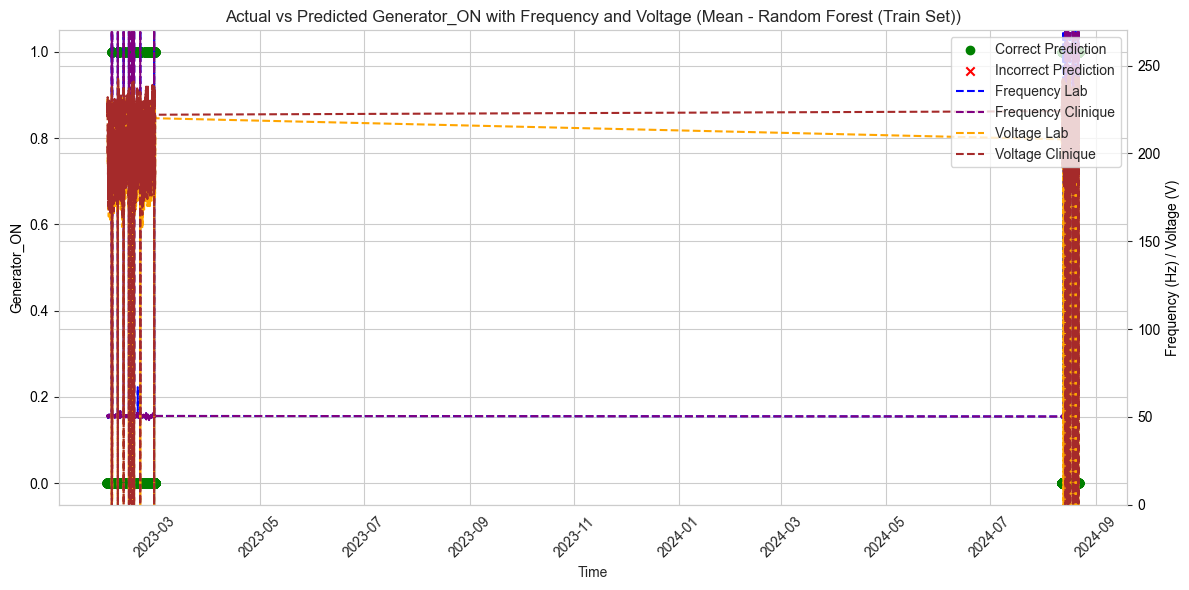

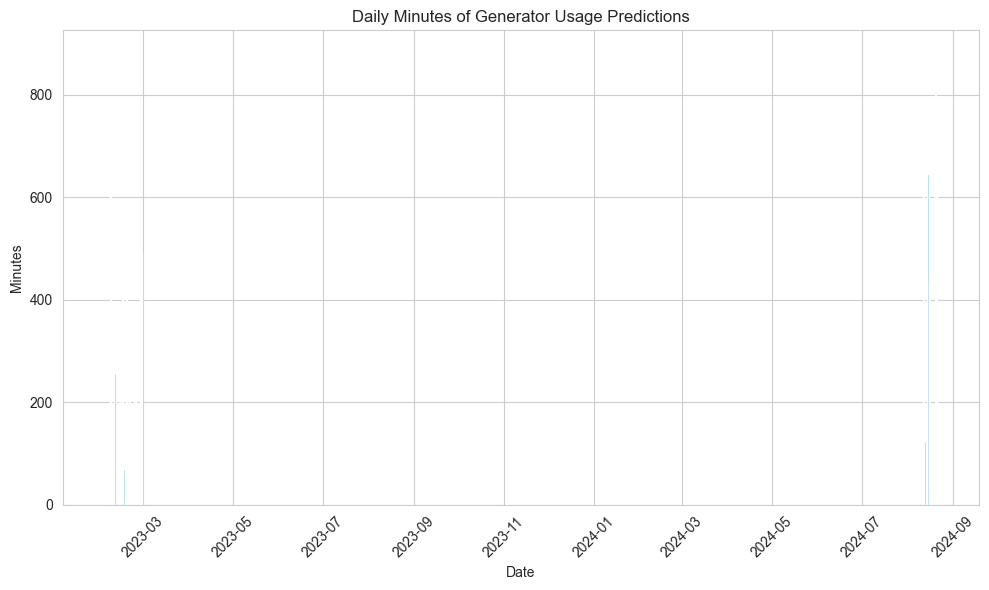

,Date,Count,Minutes,Hours
0,2023-02-03,75,150,2.500000
1,2023-02-07,352,704,11.733333
2,2023-02-10,129,258,4.300000
3,2023-02-13,145,290,4.833333
4,2023-02-15,210,420,7.000000
5,2023-02-16,35,70,1.166667
6,2023-02-18,221,442,7.366667
7,2023-02-20,194,388,6.466667
8,2023-02-23,191,382,6.366667
9,2023-02-24,197,394,6.566667


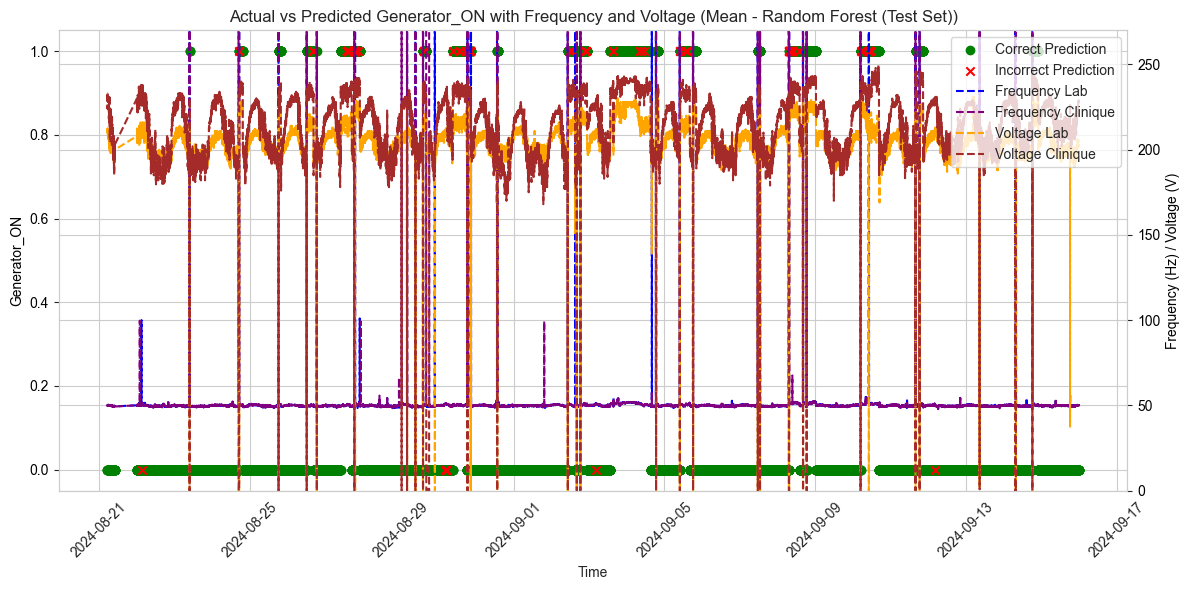

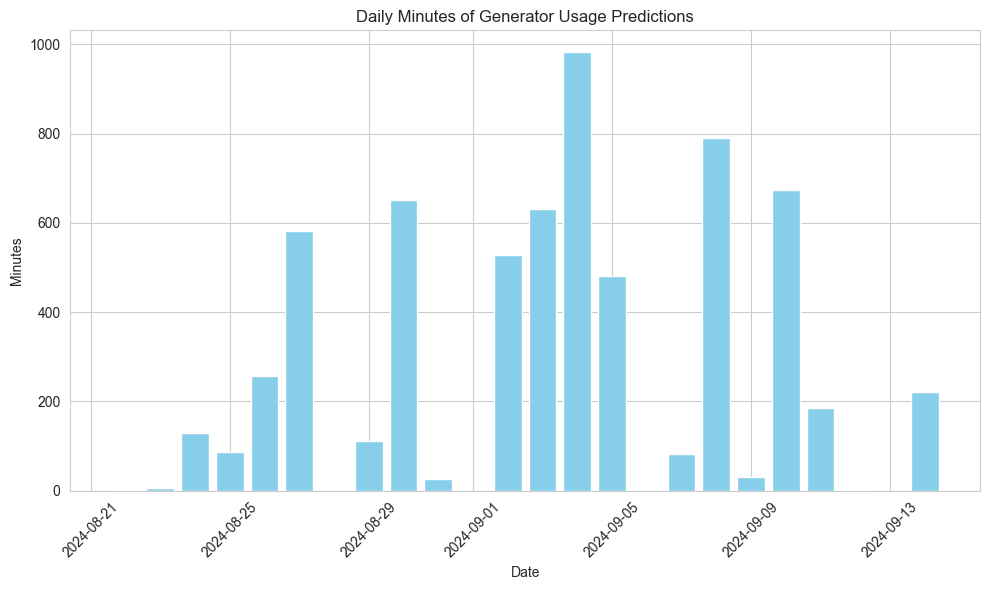

,Date,Count,Minutes,Hours
0,2024-08-22,1,2,0.033333
1,2024-08-23,3,6,0.100000
2,2024-08-24,65,130,2.166667
3,2024-08-25,43,86,1.433333
4,2024-08-26,128,256,4.266667
5,2024-08-27,291,582,9.700000
6,2024-08-29,56,112,1.866667
7,2024-08-30,325,650,10.833333
8,2024-08-31,13,26,0.433333
9,2024-09-02,264,528,8.800000


In [62]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_rf_daily_count = plot_true_predictions_histogram(train_data_ts_rf)
display(train_data_ts_rf_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_rf_daily_count = plot_true_predictions_histogram(test_data_ts_rf)
display(test_data_ts_rf_daily_count)

In [63]:
train_data_ts_rf['Generator_ON'].dtype

dtype('bool')

In [64]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_rf)
display_generator_statistics(test_data_ts_rf)

##### PREDICTION RESULT #####
Actual Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Predicted Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Actual Minutes: 3326 minutes, or 55.43 hours within 302.40 hours
Predicted Minutes: 3226 minutes, or 53.77 hours within 302.40 hours


#### 4.2.3. Using Mean of Voltage and Frequency as a Threshold and Time Series - XGBoost

In [65]:

# Step 0: Copy rf data
train_data_ts_boost = train_data_ts.copy()
test_data_ts_boost = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_boost, test_data_ts_boost = calculate_mean_flags(train_data_ts_boost, test_data_ts_boost, train_data_base, columns_to_compare)


# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]


# Step 1: Use the same data and feature columns
X_train = train_data_ts_boost[feature_columns]
y_train = train_data_ts_boost['Generator_ON']

X_test = test_data_ts_boost[feature_columns]
y_test = test_data_ts_boost['Generator_ON']

X_train['Prev_High_delta_freq_lab'] = pd.to_numeric(X_train['Prev_High_delta_freq_lab'], errors='coerce')
X_train['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_train['Prev_High_delta_freq_clinique'], errors='coerce')
X_train['Prev_High_delta_volt_lab'] = pd.to_numeric(X_train['Prev_High_delta_volt_lab'], errors='coerce')
X_train['Prev_High_delta_volt_clinique'] = pd.to_numeric(X_train['Prev_High_delta_volt_clinique'], errors='coerce')

X_test['Prev_High_delta_freq_lab'] = pd.to_numeric(X_test['Prev_High_delta_freq_lab'], errors='coerce')
X_test['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_test['Prev_High_delta_freq_clinique'], errors='coerce')
X_test['Prev_High_delta_volt_lab'] = pd.to_numeric(X_test['Prev_High_delta_volt_lab'], errors='coerce')
X_test['Prev_High_delta_volt_clinique'] = pd.to_numeric(X_test['Prev_High_delta_volt_clinique'], errors='coerce')


/var/folders/fz/752v568s4vs79b77drn5n2zm0000gp/T/ipykernel_76048/3060535340.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Prev_High_delta_freq_lab'] = pd.to_numeric(X_train['Prev_High_delta_freq_lab'], errors='coerce')
/var/folders/fz/752v568s4vs79b77drn5n2zm0000gp/T/ipykernel_76048/3060535340.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_train['Prev_High_delta_freq_clinique'], errors='coerce')
/var/folders/fz/752v568s4vs79b77

#### This section is for XGBoost parameter search using cross validation

In [66]:

'''
# Step 2: Train an XGBoost Classifier
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',  # Adjust based on your metric
    cv=3,               # Cross-validation splits
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)


# Step 3: Make Predictions on the train and test sets
train_data_ts_boost['prediction'] = xgb_clf.predict(X_train)
test_data_ts_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()
'''

'\n# Step 2: Train an XGBoost Classifier\nparam_grid = {\n    \'max_depth\': [3, 5, 7],\n    \'learning_rate\': [0.01, 0.1, 0.2],\n    \'n_estimators\': [100, 300, 500],\n    \'subsample\': [0.6, 0.8, 1.0],\n    \'colsample_bytree\': [0.6, 0.8, 1.0],\n    \'gamma\': [0, 1, 5],\n    \'reg_alpha\': [0, 0.1, 1],\n    \'reg_lambda\': [1, 10, 100]\n}\n\ngrid_search = GridSearchCV(\n    estimator=XGBClassifier(random_state=42),\n    param_grid=param_grid,\n    scoring=\'roc_auc\',  # Adjust based on your metric\n    cv=3,               # Cross-validation splits\n    verbose=2\n)\n\ngrid_search.fit(X_train, y_train)\n\nprint("Best parameters:", grid_search.best_params_)\n\n\n# Step 3: Make Predictions on the train and test sets\ntrain_data_ts_boost[\'prediction\'] = xgb_clf.predict(X_train)\ntest_data_ts_boost[\'prediction\'] = xgb_clf.predict(X_test)\n\n# Step 4: Evaluate Feature Importances\nimportances = xgb_clf.feature_importances_\n\n# Create a DataFrame for better visualization\nfeature

In [67]:
# Use the best parameters from GridSearchCV
best_params = {
    'colsample_bytree': 0.6,
    'gamma': 0,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 300,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'subsample': 1.0
}

# Initialize the model with the best parameters
final_model = XGBClassifier(
    random_state=42,
    **best_params
)

# Fit the model on the entire training data
final_model.fit(X_train, y_train)

# Make predictions on the test set
train_data_ts_boost['prediction'] = final_model.predict(X_train)
test_data_ts_boost['prediction'] = final_model.predict(X_test)

# Evaluate the model on the test set
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Classification report
print("Classification Report:")
print(classification_report(y_test, test_data_ts_boost['prediction']))

# AUC-ROC score
print("AUC-ROC Score:")
y_test_proba = final_model.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_test_proba))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_data_ts_boost['prediction']))

Classification Report:
              precision    recall  f1-score   support

       False       0.99      1.00      1.00     14818
        True       1.00      0.97      0.98      3326

    accuracy                           0.99     18144
   macro avg       0.99      0.99      0.99     18144
weighted avg       0.99      0.99      0.99     18144

AUC-ROC Score:
0.9994344082829166
Confusion Matrix:
[[14805    13]
 [   94  3232]]


In [68]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_ts_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_ts_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 0.9963991769547325
Confusion Matrix:
[[23137    74]
 [   24  3981]]
Precision: 0.981750924784217
Recall: 0.9940074906367041
Train data prediction distribution (XGBoost):
prediction
0    23161
1     4055
Name: count, dtype: int64


In [69]:
# Evaluate on the test set
print("\nTest Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_ts_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(test_data_ts_boost['prediction'].value_counts())


Test Set Evaluation (XGBoost):
Accuracy: 0.994102733686067
Confusion Matrix:
[[14805    13]
 [   94  3232]]
Precision: 0.9959938366718027
Recall: 0.9717378232110644
Test data prediction distribution (XGBoost):
prediction
0    14899
1     3245
Name: count, dtype: int64


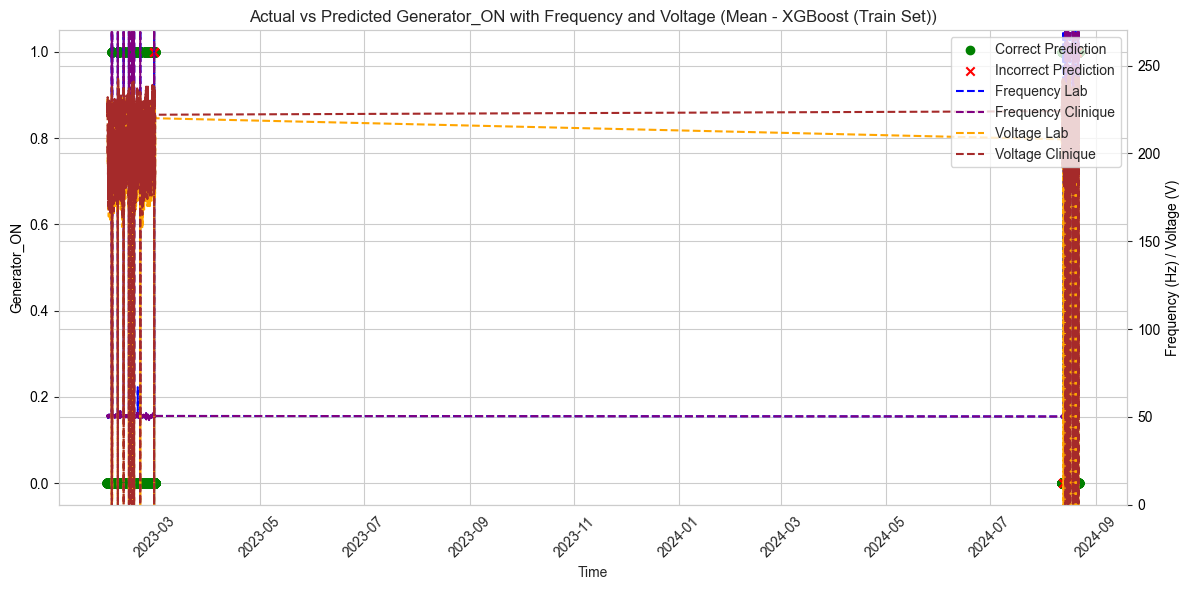

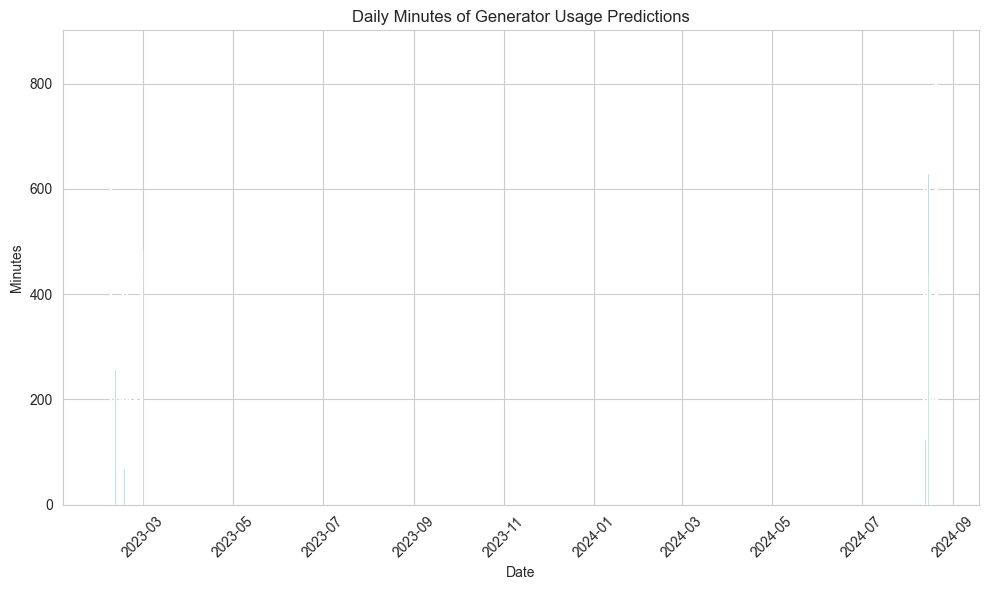

,Date,Count,Minutes,Hours
0,2023-02-03,75,150,2.500000
1,2023-02-07,352,704,11.733333
2,2023-02-10,129,258,4.300000
3,2023-02-13,145,290,4.833333
4,2023-02-15,210,420,7.000000
5,2023-02-16,35,70,1.166667
6,2023-02-18,221,442,7.366667
7,2023-02-20,194,388,6.466667
8,2023-02-23,191,382,6.366667
9,2023-02-24,197,394,6.566667


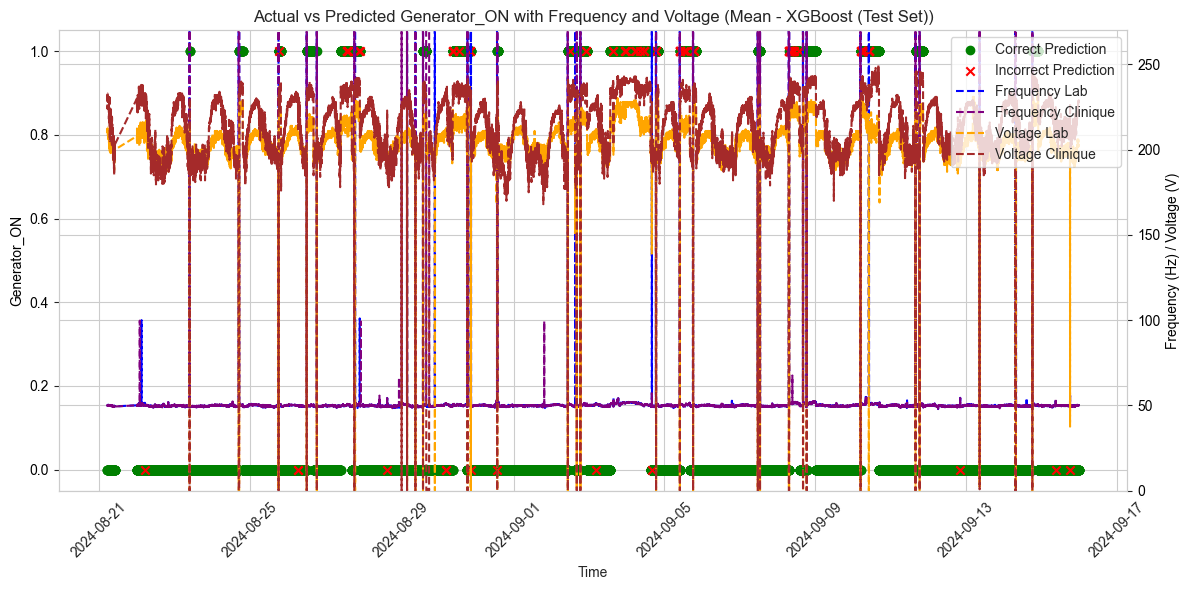

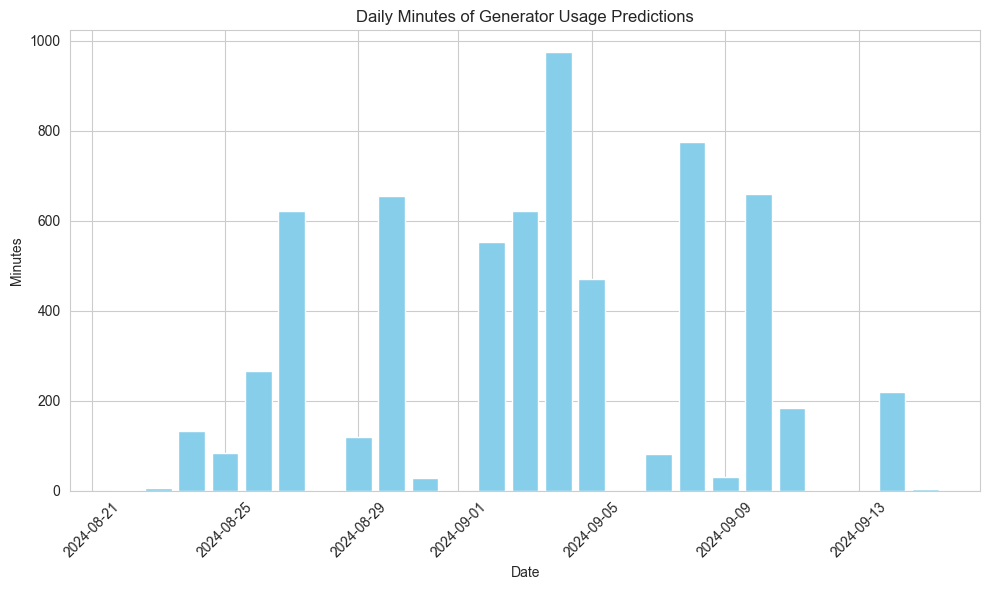

,Date,Count,Minutes,Hours
0,2024-08-22,1,2,0.033333
1,2024-08-23,3,6,0.100000
2,2024-08-24,66,132,2.200000
3,2024-08-25,42,84,1.400000
4,2024-08-26,133,266,4.433333
5,2024-08-27,311,622,10.366667
6,2024-08-28,1,2,0.033333
7,2024-08-29,60,120,2.000000
8,2024-08-30,327,654,10.900000
9,2024-08-31,14,28,0.466667


In [70]:
# For Boosting Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_boost, model_name="Mean - XGBoost (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_boost_daily_count = plot_true_predictions_histogram(train_data_ts_boost)
display(train_data_ts_boost_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_boost, model_name="Mean - XGBoost (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_boost_daily_count = plot_true_predictions_histogram(test_data_ts_boost)
display(test_data_ts_boost_daily_count)

In [71]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_boost)
display_generator_statistics(test_data_ts_boost)

##### PREDICTION RESULT #####
Actual Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Predicted Minutes: 4055 minutes, or 67.58 hours within 453.60 hours
Actual Minutes: 3326 minutes, or 55.43 hours within 302.40 hours
Predicted Minutes: 3245 minutes, or 54.08 hours within 302.40 hours


### 4.3. Correlation Feature

In this section we're applying additional feature using the : 
- Hidden Markov Model : Detecting states

In [72]:
### Applying Hidden Markov Model

# Adding the new HMM related features
# Insert variables of values 
n_states=10

hmm_columns  = [freq_a, freq_b, volt_a, volt_b]

train_data_ts_co = train_data_ts.copy()
test_data_ts_co = test_data_ts.copy()

train_data_ts_co.sort_values('Time', ascending=True, inplace=True)
test_data_ts_co.sort_values('Time', ascending=True, inplace=True)

train_data_ts_co, hmm_models, hmm_features = generate_hmm(train_data_ts_co, hmm_columns, n_states=n_states)
test_data_ts_co = apply_hmm(test_data_ts_co, hmm_columns, hmm_models)

display(train_data_ts_co)
display(test_data_ts_co)

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_0,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_1,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_2,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_3,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_4,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_5,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_6,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_7,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_8,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_9
0,2023-02-01 00:00:00,50.5,50.4,223.0,223.0,False,False,False,True,True,...,False,False,False,False,False,False,True,False,False,False
1,2023-02-01 00:02:00,50.6,50.5,223.0,224.0,False,False,False,True,True,...,False,False,False,False,False,True,False,False,False,False
2,2023-02-01 00:04:00,50.6,50.6,223.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,True,False,False,False
3,2023-02-01 00:06:00,50.6,50.5,224.0,225.0,False,False,False,True,True,...,False,False,False,False,False,True,False,False,False,False
4,2023-02-01 00:08:00,50.5,50.6,222.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27115,2024-08-21 23:50:00,50.0,49.8,209.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,True,False,False,False
27116,2024-08-21 23:52:00,50.1,50.0,208.0,223.0,False,False,False,True,True,...,False,False,False,False,False,True,False,False,False,False
27117,2024-08-21 23:54:00,50.4,50.0,206.0,224.0,False,False,False,True,True,...,False,False,False,False,False,False,True,False,False,False
27118,2024-08-21 23:56:00,50.0,50.4,208.0,231.0,False,False,False,True,True,...,True,False,False,False,False,False,False,False,False,False


,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_0,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_1,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_2,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_3,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_4,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_5,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_6,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_7,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_8,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_9
27216,2024-08-21 05:12:00,50.3,50.2,213.0,233.0,False,False,False,True,True,...,False,False,False,False,False,False,True,False,False,False
27217,2024-08-21 05:14:00,50.1,50.0,213.0,233.0,False,False,False,True,True,...,True,False,False,False,False,False,False,False,False,False
27218,2024-08-21 05:16:00,50.1,50.0,210.0,224.0,False,False,False,True,True,...,True,False,False,False,False,False,False,False,False,False
27219,2024-08-21 05:18:00,50.0,50.1,213.0,225.0,False,False,False,True,True,...,True,False,False,False,False,False,False,False,False,False
27220,2024-08-21 05:20:00,49.6,49.6,212.0,231.0,False,False,False,True,True,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39355,2024-09-15 23:50:00,50.1,50.1,202.0,229.0,False,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False
39356,2024-09-15 23:52:00,50.1,50.1,202.0,228.0,False,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False
39357,2024-09-15 23:54:00,50.0,50.0,203.0,229.0,False,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False
39358,2024-09-15 23:56:00,50.1,50.1,202.0,229.0,False,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False


/var/folders/fz/752v568s4vs79b77drn5n2zm0000gp/T/ipykernel_76048/2959736297.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.sort_values('Time', ascending=True, inplace=True)



Mean values per HMM state for Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire):
HMM_State_Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)
5      49.875410
6      49.887023
0      50.278079
3      50.787988
7    4209.328571
8    4367.000000
9    4376.500000
1    5618.000000
2    9756.500000
Name: Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire), dtype: float64


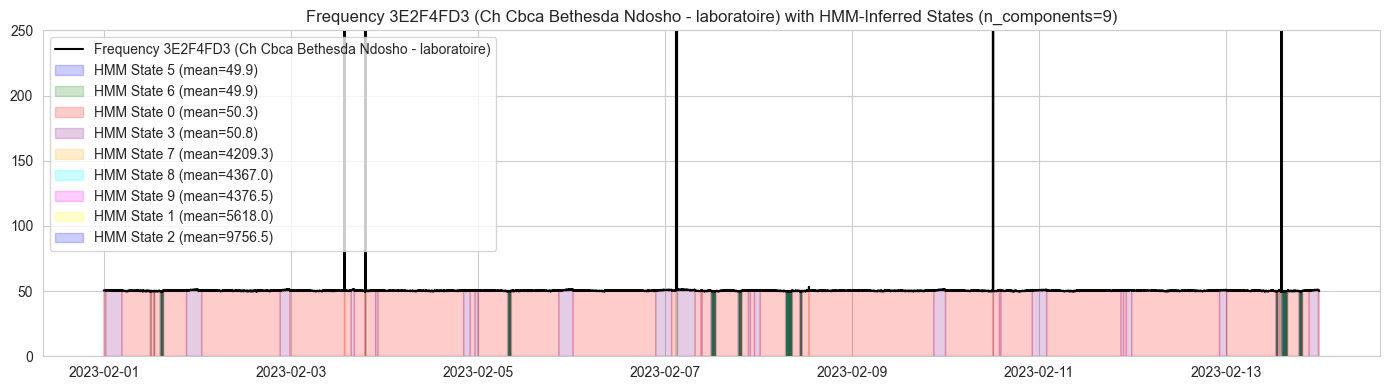


Mean values per HMM state for Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique):
HMM_State_Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)
6      49.704545
8      49.725926
0      50.107930
3      50.371528
9      50.782862
7      51.160000
1      51.720000
5    5328.461538
2    9804.000000
Name: Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique), dtype: float64


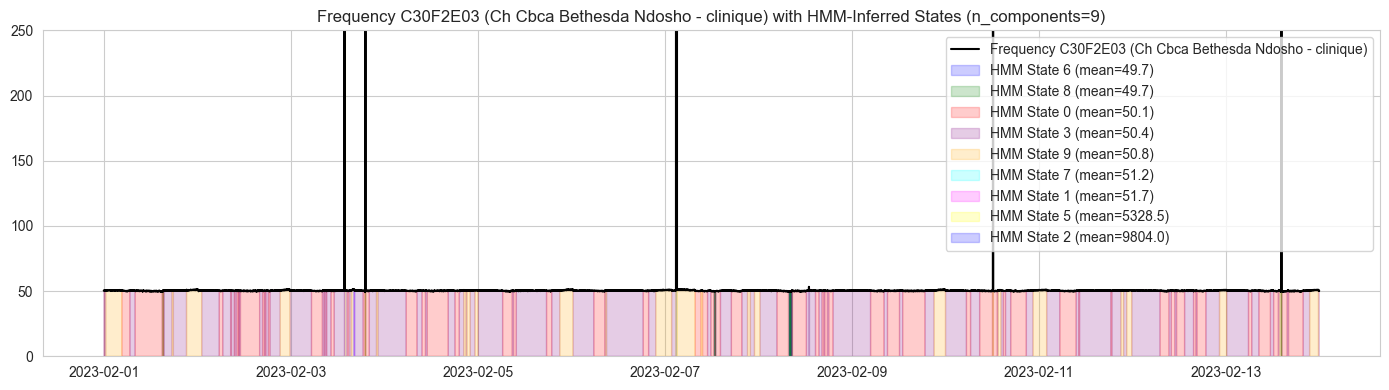


Mean values per HMM state for Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire):
HMM_State_Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)
2      0.100714
9    183.053937
1    193.263469
5    200.639511
6    201.081081
8    208.441472
4    208.800000
3    216.347458
0    222.335950
7    228.174525
Name: Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire), dtype: float64


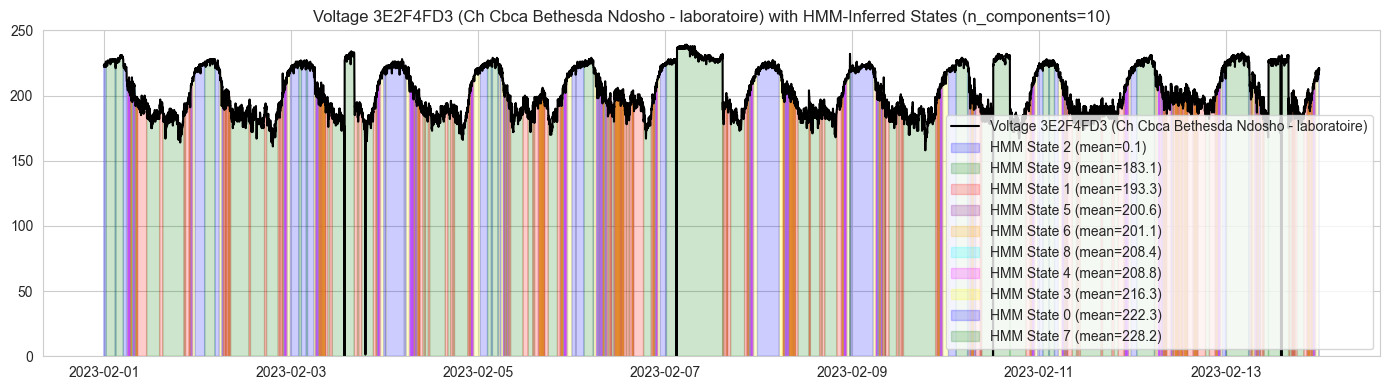


Mean values per HMM state for Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique):
HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)
2      0.108769
1    186.712635
9    198.141323
4    209.458333
8    209.637755
5    221.447038
6    221.587156
0    226.958576
3    232.619503
7    237.526316
Name: Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique), dtype: float64


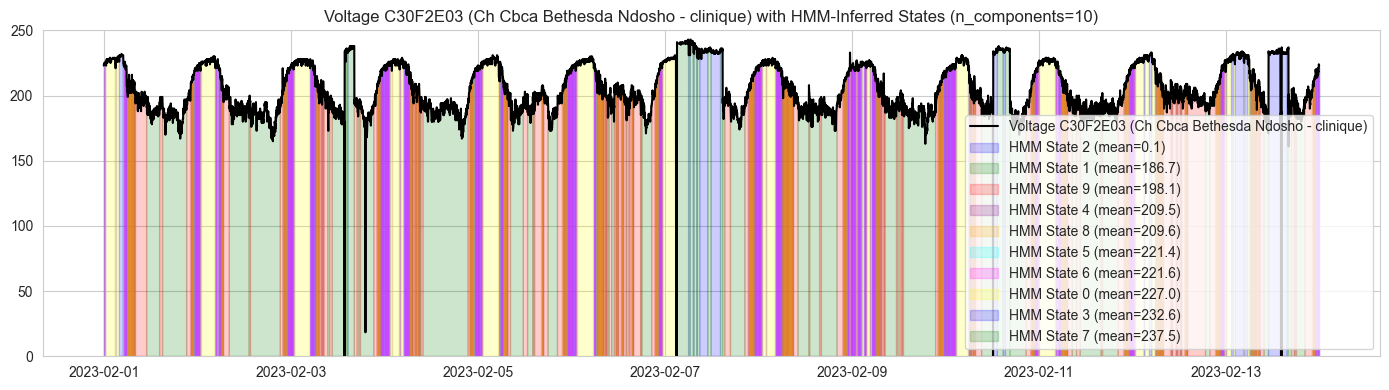

In [73]:
#### SHOWING THE RESULT OF HMM SIGNAL
    
# Create the signal
start_date = '2023-02-01 00:00:00'
finished_date = '2023-02-13 23:59:59'
filtered_data = train_data_ts_co[(train_data_ts_co['Time'] >= start_date) & (train_data_ts_co['Time'] <= finished_date)]
filtered_data.sort_values('Time', ascending=True, inplace=True)

show_hmm_result(filtered_data, hmm_columns, y_max=250)

In [74]:
hmm_features

['HMM_State_Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)_0',
 'HMM_State_Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)_1',
 'HMM_State_Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)_2',
 'HMM_State_Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)_3',
 'HMM_State_Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)_4',
 'HMM_State_Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)_5',
 'HMM_State_Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)_6',
 'HMM_State_Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)_7',
 'HMM_State_Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)_8',
 'HMM_State_Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)_9',
 'HMM_State_Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_0',
 'HMM_State_Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_1',
 'HMM_State_Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)_2',
 'HMM_State_Frequency C30F2E03 (Ch

#### 4.3.1. Adding the Correlation functions (HMM and Ruptures)  - Logistic Regression

Train Accuracy: 0.99
Test Accuracy: 0.98
Top 20 features sorted by absolute coefficient value:


/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Feature,Coefficient
89,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda N...,6.248408
79,HMM_State_Voltage 3E2F4FD3 (Ch Cbca Bethesda N...,5.298648
24,Hour_4,-4.642925
71,HMM_State_Frequency C30F2E03 (Ch Cbca Bethesda...,-4.540943
23,Hour_3,-4.277771
69,HMM_State_Frequency C30F2E03 (Ch Cbca Bethesda...,3.502690
63,HMM_State_Frequency C30F2E03 (Ch Cbca Bethesda...,3.501996
25,Hour_5,-3.494064
75,HMM_State_Voltage 3E2F4FD3 (Ch Cbca Bethesda N...,3.401345
22,Hour_2,-3.302206


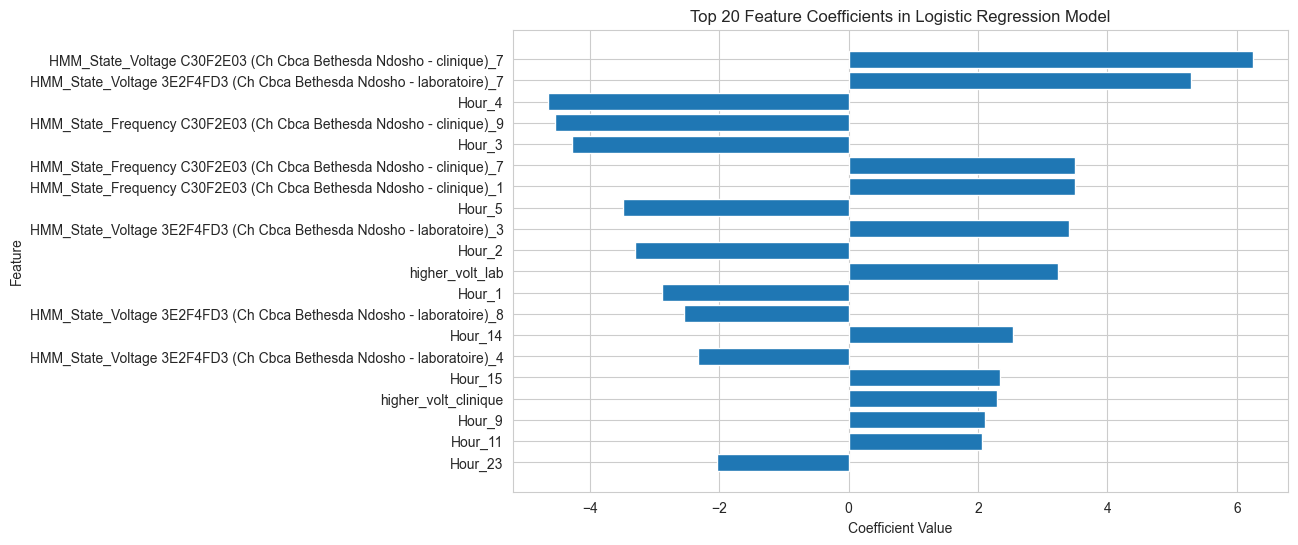

In [75]:
# Step 1: Create copies of the original data
train_data_ts_co_lg = train_data_ts_co.copy()
test_data_ts_co_lg = test_data_ts_co.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_ts_co_lg, test_data_ts_co_lg = calculate_mean_flags(train_data_ts_co_lg, test_data_ts_co_lg, train_data_base,
                                                         columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a,
    freq_b,
    volt_a,
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

feature_columns = feature_columns + hmm_features

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_co_lg[feature_columns]
y_train = train_data_ts_co_lg['Generator_ON']

X_test = test_data_ts_co_lg[feature_columns]
y_test = test_data_ts_co_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Logistic Regression model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_co_lg['prediction'] = clf.predict(X_train)
test_data_ts_co_lg['prediction'] = clf.predict(X_test)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_ts_co_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_ts_co_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Step 4: Get the feature coefficients (importance in logistic regression)
coefficients = clf.coef_[0]  # Extract coefficients from the trained model

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': coefficients
})

# Sort the features by absolute value of the coefficient and keep the top 20
top_20_features = feature_importance_df.reindex(
    feature_importance_df['Coefficient'].abs().sort_values(ascending=False).index
).head(20)

# Display the top 20 most significant features
print("Top 20 features sorted by absolute coefficient value:")
display(top_20_features)

# Visualize the top 20 feature coefficients
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Coefficient'])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Top 20 Feature Coefficients in Logistic Regression Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most significant features on top
plt.show()

In [76]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_co_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_co_lg['prediction'].value_counts())

# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_co_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_co_lg['prediction'].value_counts())

print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_co_lg)
display_generator_statistics(test_data_ts_co_lg)

Train Set Evaluation:
Accuracy: 0.9945252792475014
Confusion Matrix:
[[23135    76]
 [   73  3932]]
Precision: 0.9810379241516967
Recall: 0.981772784019975
Train data prediction distribution:
prediction
False    23208
True      4008
Name: count, dtype: int64
Test Set Evaluation:
Accuracy: 0.9836860670194003
Confusion Matrix:
[[14814     4]
 [  292  3034]]
Precision: 0.9986833443054641
Recall: 0.9122068550811786
Test data prediction distribution:
prediction
False    15106
True      3038
Name: count, dtype: int64
##### PREDICTION RESULT #####
Actual Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Predicted Minutes: 4008 minutes, or 66.80 hours within 453.60 hours
Actual Minutes: 3326 minutes, or 55.43 hours within 302.40 hours
Predicted Minutes: 3038 minutes, or 50.63 hours within 302.40 hours


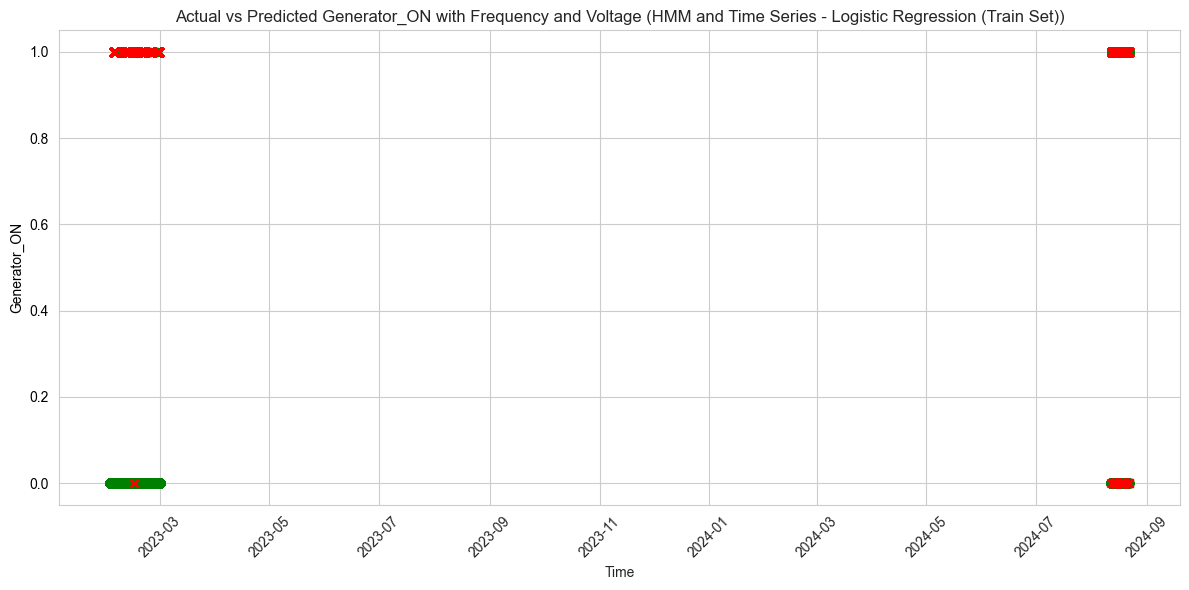

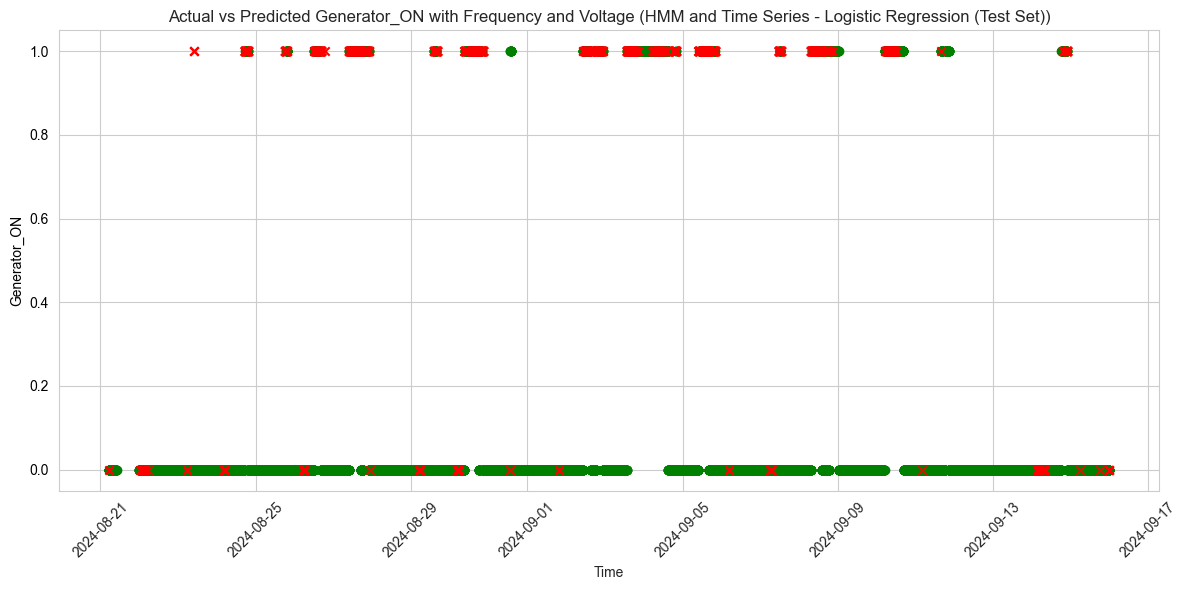

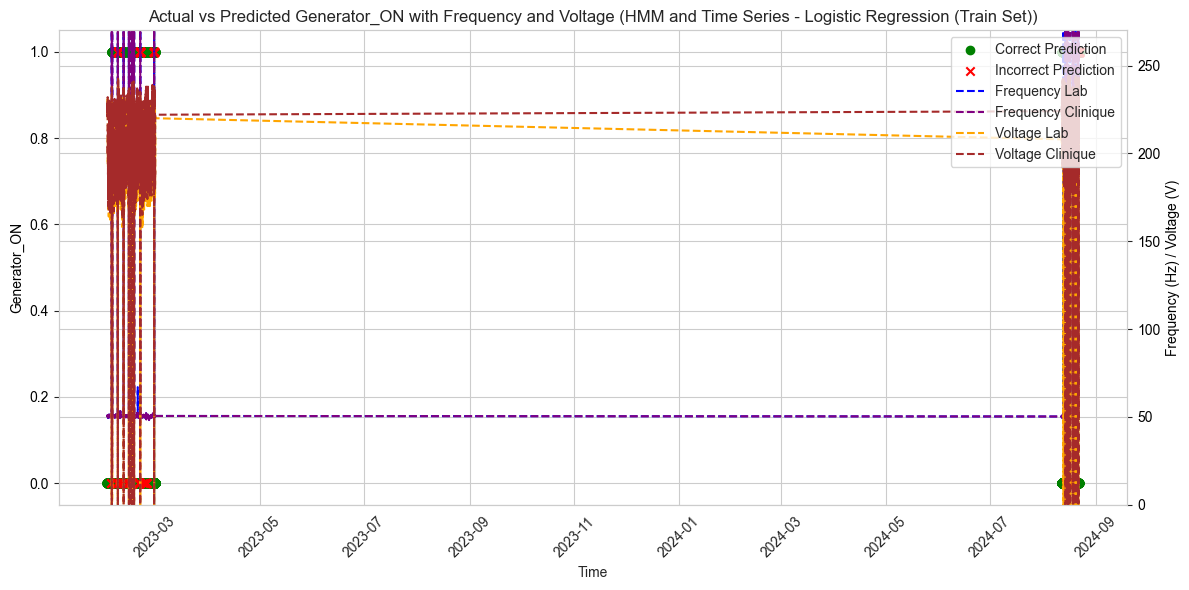

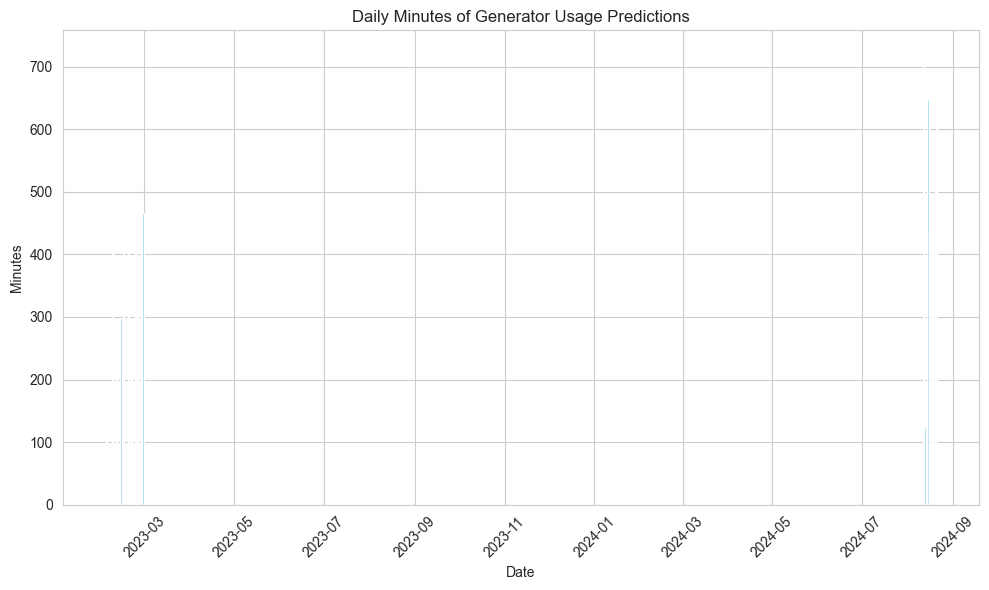

,Date,Count,Minutes,Hours
0,2023-02-02,1,2,0.033333
1,2023-02-03,76,152,2.533333
2,2023-02-06,8,16,0.266667
3,2023-02-07,207,414,6.900000
4,2023-02-08,4,8,0.133333
5,2023-02-09,1,2,0.033333
6,2023-02-10,129,258,4.300000
7,2023-02-12,4,8,0.133333
8,2023-02-13,149,298,4.966667
9,2023-02-14,2,4,0.066667


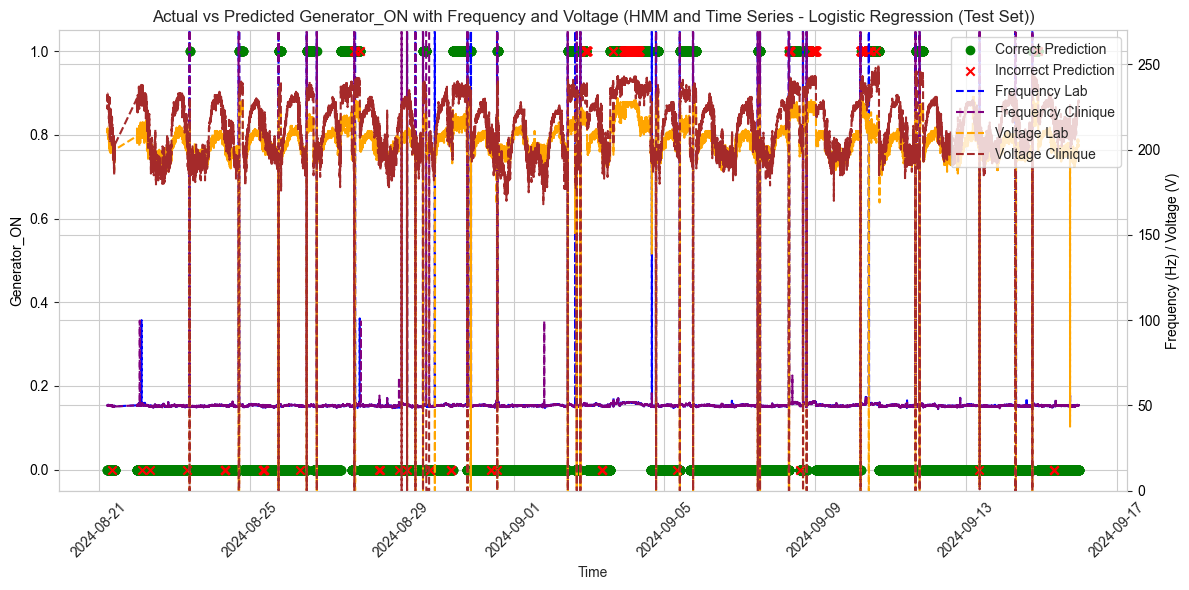

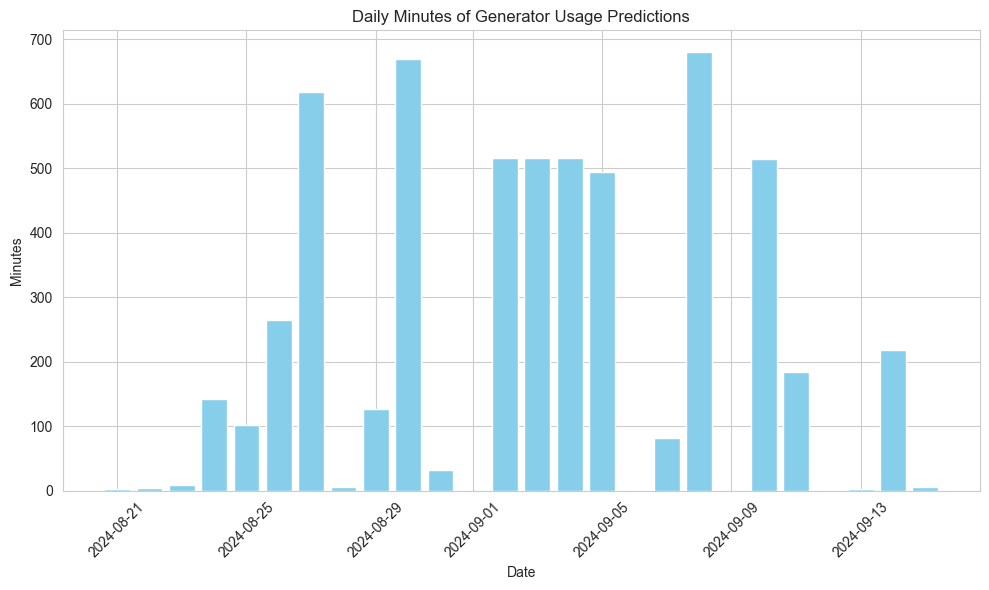

,Date,Count,Minutes,Hours
0,2024-08-21,1,2,0.033333
1,2024-08-22,2,4,0.066667
2,2024-08-23,4,8,0.133333
3,2024-08-24,71,142,2.366667
4,2024-08-25,51,102,1.700000
5,2024-08-26,132,264,4.400000
6,2024-08-27,309,618,10.300000
7,2024-08-28,3,6,0.100000
8,2024-08-29,63,126,2.100000
9,2024-08-30,335,670,11.166667


In [77]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="HMM and Time Series - Logistic Regression (Train Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="HMM and Time Series - Logistic Regression (Test Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_lg, model_name="HMM and Time Series - Logistic Regression (Train Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_lg_daily_count = plot_true_predictions_histogram(train_data_ts_lg)
display(train_data_ts_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_lg, model_name="HMM and Time Series - Logistic Regression (Test Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_lg_daily_count = plot_true_predictions_histogram(test_data_ts_lg)
display(test_data_ts_lg_daily_count)


#### 4.3.2. Adding the Correlation functions (HMM)  - Random Forrest

Top 20 features sorted by importance:


,Feature,Importance
3,Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - cl...,0.239700
89,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda N...,0.158307
2,Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - la...,0.085415
85,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda N...,0.083421
1,Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - ...,0.048845
79,HMM_State_Voltage 3E2F4FD3 (Ch Cbca Bethesda N...,0.045659
0,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - ...,0.034153
6,higher_volt_lab,0.021531
55,HMM_State_Frequency 3E2F4FD3 (Ch Cbca Bethesda...,0.017033
82,HMM_State_Voltage C30F2E03 (Ch Cbca Bethesda N...,0.016859


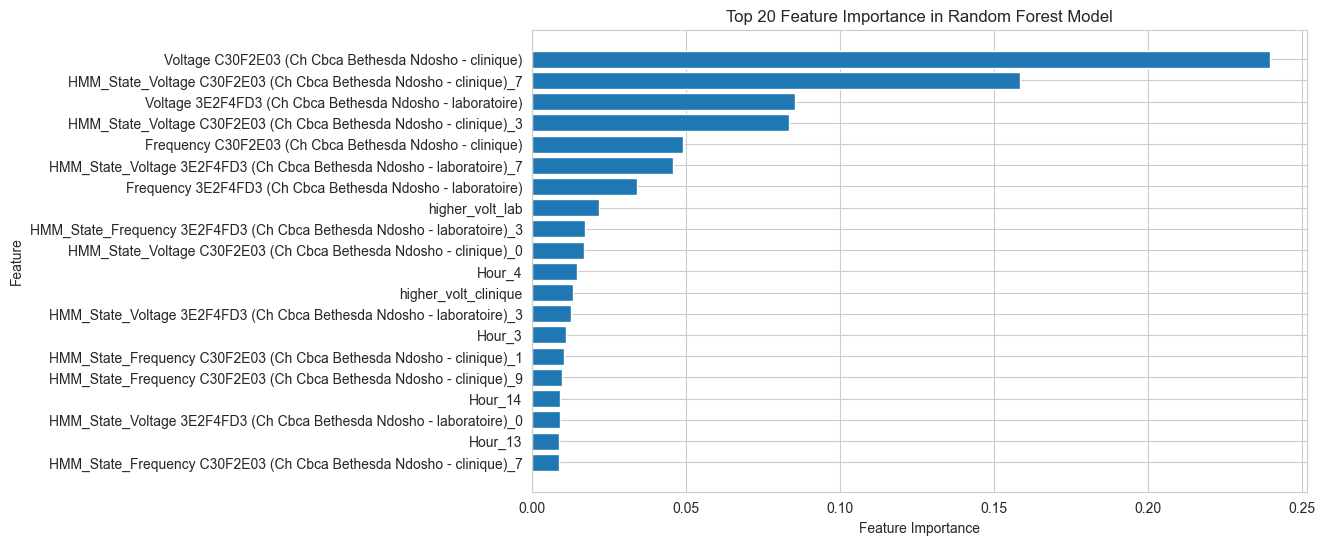

In [78]:
# Step 1: Create copies of the original data
train_data_ts_co_rf = train_data_ts_co.copy()
test_data_ts_co_rf = test_data_ts_co.copy()


# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_co_rf[feature_columns]
y_train = train_data_ts_co_rf['Generator_ON']

X_test = test_data_ts_co_rf[feature_columns]
y_test = test_data_ts_co_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_co_rf['prediction'] = clf.predict(X_train)
test_data_ts_co_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 15 most important features
print("Top 20 features sorted by importance:")
display(top_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

Evaluating the train and test set

Train Set Evaluation:
Accuracy: 1.0
Confusion Matrix:
[[23211     0]
 [    0  4005]]
Precision: 1.0
Recall: 1.0
Train data prediction distribution:
prediction
False    23211
True      4005
Name: count, dtype: int64
Test Set Evaluation:
Accuracy: 0.9872134038800705
Confusion Matrix:
[[14814     4]
 [  228  3098]]
Precision: 0.9987105093488072
Recall: 0.931449188214071
Test data prediction distribution:
prediction
False    15042
True      3102
Name: count, dtype: int64


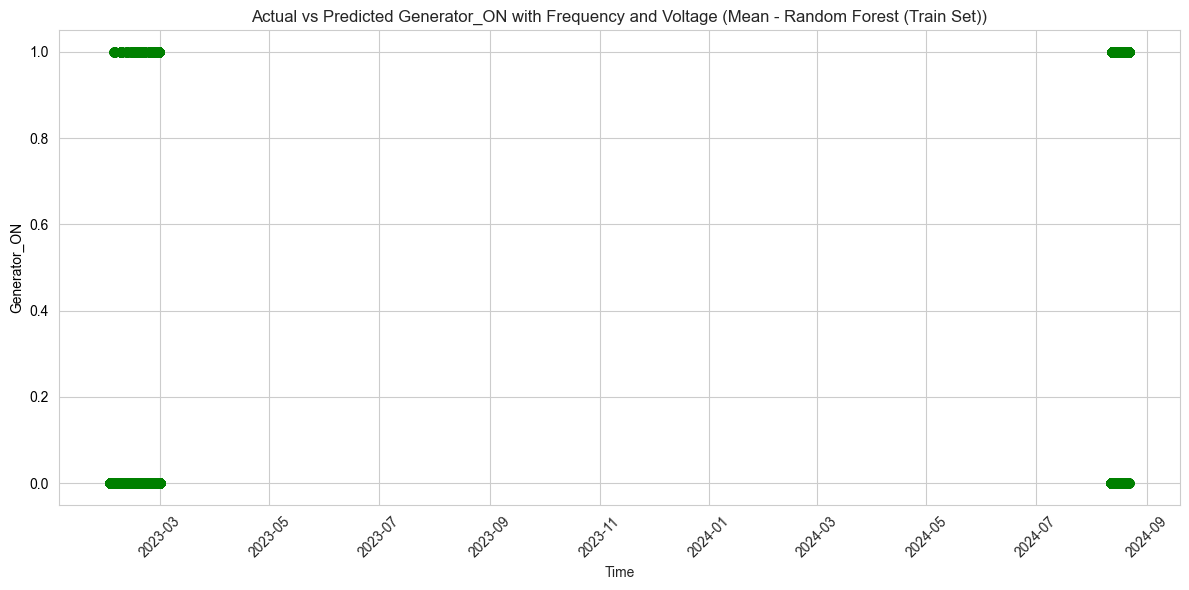

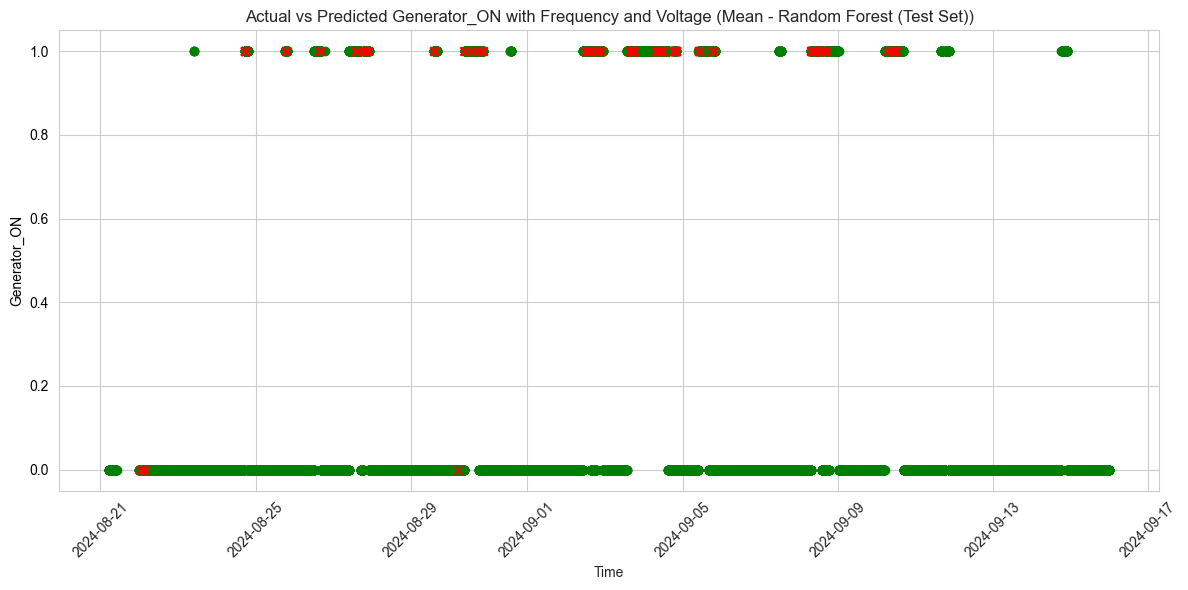

In [79]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_co_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_co_rf['prediction'].value_counts())
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_co_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_co_rf['prediction'].value_counts())

# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_co_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False,
                            include_frequency=False)
plot_predictions_vs_actuals(test_data_ts_co_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False,
                            include_frequency=False)

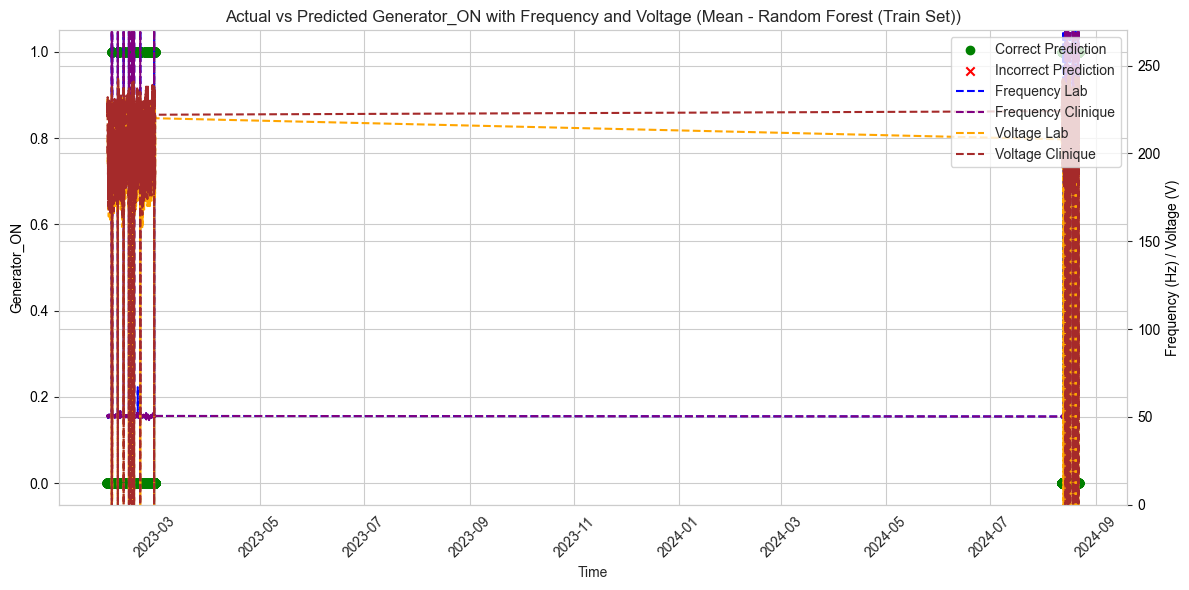

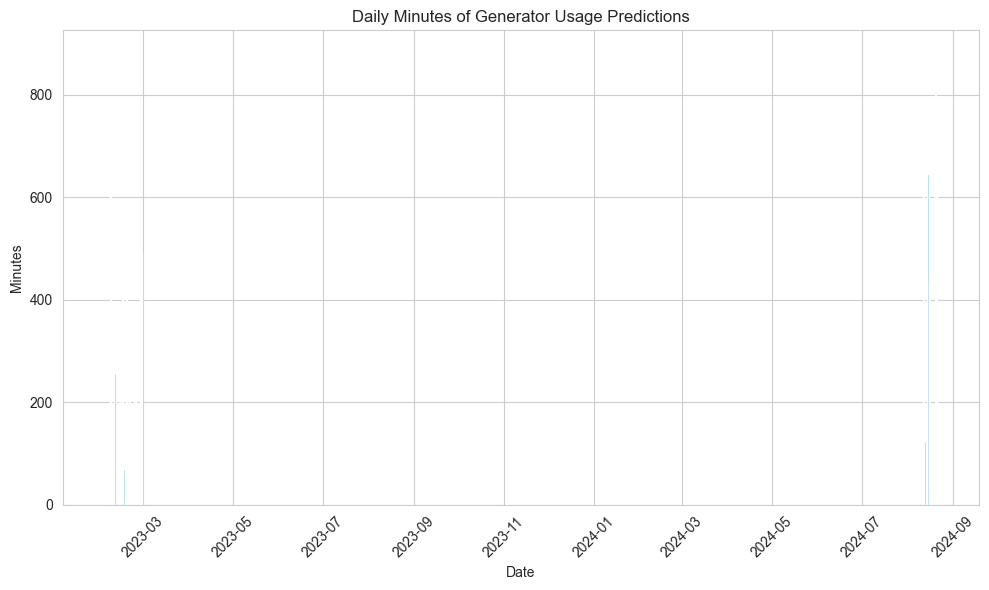

,Date,Count,Minutes,Hours
0,2023-02-03,75,150,2.500000
1,2023-02-07,352,704,11.733333
2,2023-02-10,129,258,4.300000
3,2023-02-13,145,290,4.833333
4,2023-02-15,210,420,7.000000
5,2023-02-16,35,70,1.166667
6,2023-02-18,221,442,7.366667
7,2023-02-20,194,388,6.466667
8,2023-02-23,191,382,6.366667
9,2023-02-24,197,394,6.566667


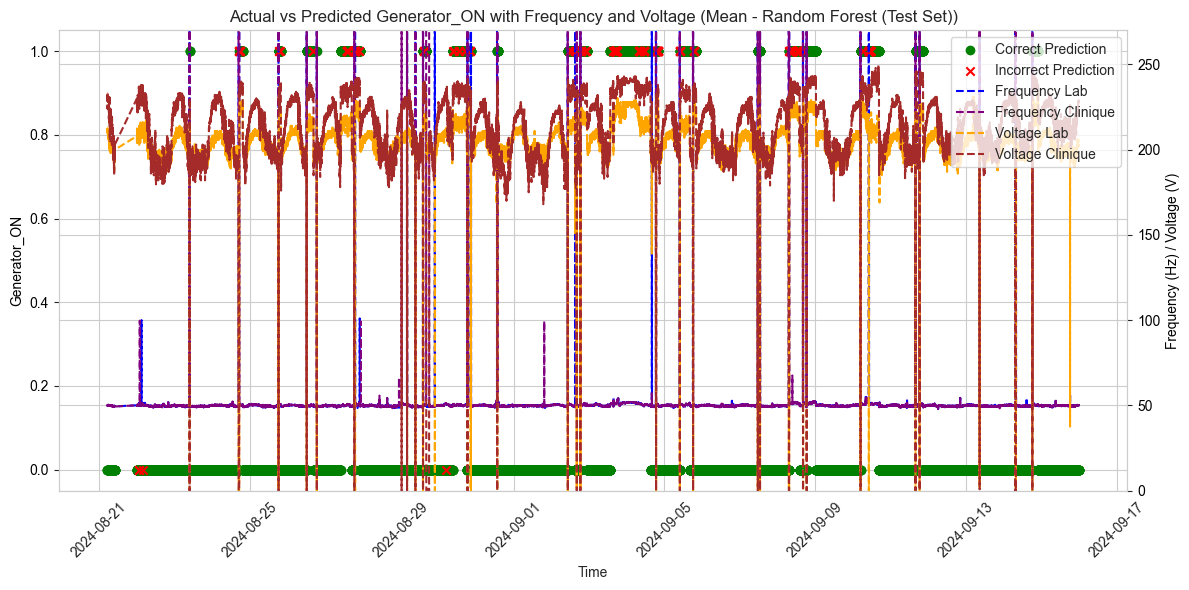

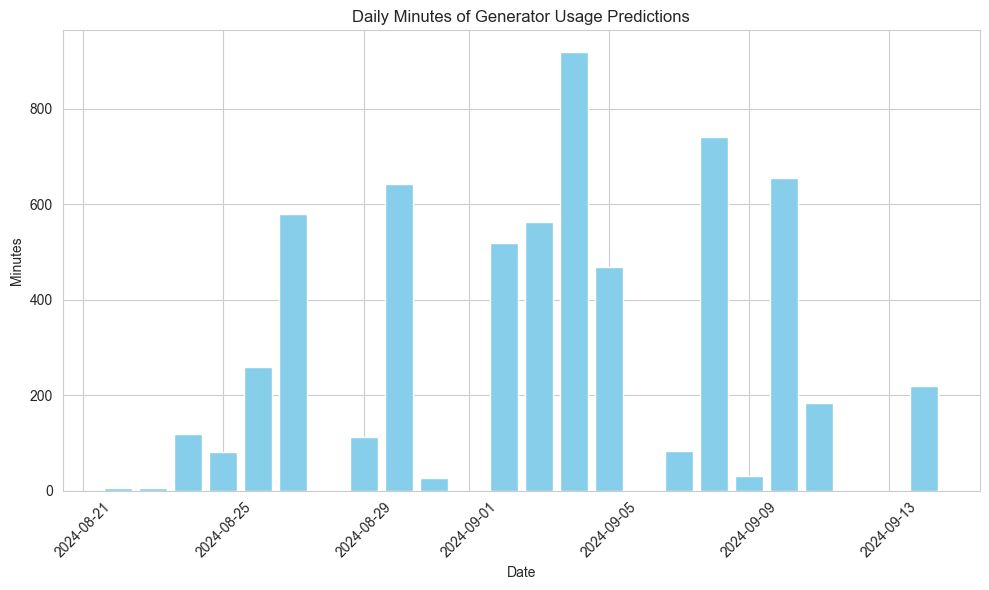

,Date,Count,Minutes,Hours
0,2024-08-22,3,6,0.100000
1,2024-08-23,3,6,0.100000
2,2024-08-24,59,118,1.966667
3,2024-08-25,40,80,1.333333
4,2024-08-26,129,258,4.300000
5,2024-08-27,290,580,9.666667
6,2024-08-29,56,112,1.866667
7,2024-08-30,321,642,10.700000
8,2024-08-31,13,26,0.433333
9,2024-09-02,259,518,8.633333


##### PREDICTION RESULT #####
Actual Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Predicted Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Actual Minutes: 3326 minutes, or 55.43 hours within 302.40 hours
Predicted Minutes: 3102 minutes, or 51.70 hours within 302.40 hours


In [80]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_co_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
train_data_ts_co_rf_daily_count = plot_true_predictions_histogram(train_data_ts_co_rf)
display(train_data_ts_co_rf_daily_count)

# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_co_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
test_data_ts_co_rf_daily_count = plot_true_predictions_histogram(test_data_ts_co_rf)
display(test_data_ts_co_rf_daily_count)
train_data_ts_co_rf['Generator_ON'].dtype

print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_co_rf)
display_generator_statistics(test_data_ts_co_rf)

#### 4.3.3. Adding the Correlation functions (HMM) - XGBoost

In [81]:
# Step 0: Copy rf data
train_data_ts_co_boost = train_data_ts_co.copy()
test_data_ts_co_boost = test_data_ts_co.copy()

# Step 1: Use the same data and feature columns (with copy to avoid SettingWithCopyWarning)
X_train = train_data_ts_co_boost[feature_columns].copy()
y_train = train_data_ts_co_boost['Generator_ON']

X_test = test_data_ts_co_boost[feature_columns].copy()
y_test = test_data_ts_co_boost['Generator_ON']

# Convert specific columns to numeric
cols_to_convert = [
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_train[cols_to_convert] = X_train[cols_to_convert].apply(pd.to_numeric, errors='coerce')
X_test[cols_to_convert] = X_test[cols_to_convert].apply(pd.to_numeric, errors='coerce')

#### This section is for XGBoost parameter search using cross validation

In [82]:
'''
# Step 2: Train an XGBoost Classifier
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',  # Adjust based on your metric
    cv=3,               # Cross-validation splits
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)


# Step 3: Make Predictions on the train and test sets
train_data_ts_co_boost['prediction'] = xgb_clf.predict(X_train)
test_data_ts_co_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()
'''

'\n# Step 2: Train an XGBoost Classifier\nparam_grid = {\n    \'max_depth\': [3, 5, 7],\n    \'learning_rate\': [0.01, 0.1, 0.2],\n    \'n_estimators\': [100, 300, 500],\n    \'subsample\': [0.6, 0.8, 1.0],\n    \'colsample_bytree\': [0.6, 0.8, 1.0],\n    \'gamma\': [0, 1, 5],\n    \'reg_alpha\': [0, 0.1, 1],\n    \'reg_lambda\': [1, 10, 100]\n}\n\ngrid_search = GridSearchCV(\n    estimator=XGBClassifier(random_state=42),\n    param_grid=param_grid,\n    scoring=\'roc_auc\',  # Adjust based on your metric\n    cv=3,               # Cross-validation splits\n    verbose=2\n)\n\ngrid_search.fit(X_train, y_train)\n\nprint("Best parameters:", grid_search.best_params_)\n\n\n# Step 3: Make Predictions on the train and test sets\ntrain_data_ts_co_boost[\'prediction\'] = xgb_clf.predict(X_train)\ntest_data_ts_co_boost[\'prediction\'] = xgb_clf.predict(X_test)\n\n# Step 4: Evaluate Feature Importances\nimportances = xgb_clf.feature_importances_\n\n# Create a DataFrame for better visualization\nf

In [83]:
# Use the best parameters from GridSearchCV - Saved so no need to re run the parameters. Only re run if we have additional features or different training data 

best_params = {
    'colsample_bytree': 0.6,
    'gamma': 0,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 300,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'subsample': 1.0
}


# Initialize the model with the best parameters
final_model = XGBClassifier(
    random_state=42,
    **best_params
)

# Fit the model on the entire training data
final_model.fit(X_train, y_train)

# Make predictions on the test set
train_data_ts_co_boost['prediction'] = final_model.predict(X_train)
test_data_ts_co_boost['prediction'] = final_model.predict(X_test)

# Evaluate the model on the test set
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Classification report
print("Classification Report:")
print(classification_report(y_test, test_data_ts_co_boost['prediction']))

# AUC-ROC score
print("AUC-ROC Score:")
y_test_proba = final_model.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_test_proba))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_data_ts_co_boost['prediction']))

# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_ts_co_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_ts_co_boost['prediction'].value_counts())
# Evaluate on the test set
print("\nTest Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_ts_co_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(test_data_ts_co_boost['prediction'].value_counts())

Classification Report:
              precision    recall  f1-score   support

       False       0.99      1.00      1.00     14818
        True       1.00      0.96      0.98      3326

    accuracy                           0.99     18144
   macro avg       0.99      0.98      0.99     18144
weighted avg       0.99      0.99      0.99     18144

AUC-ROC Score:
0.9997239608066346
Confusion Matrix:
[[14808    10]
 [  136  3190]]
Train Set Evaluation (XGBoost):
Accuracy: 0.9982730746619636
Confusion Matrix:
[[23176    35]
 [   12  3993]]
Precision: 0.9913108242303873
Recall: 0.997003745318352
Train data prediction distribution (XGBoost):
prediction
0    23188
1     4028
Name: count, dtype: int64

Test Set Evaluation (XGBoost):
Accuracy: 0.9919532627865961
Confusion Matrix:
[[14808    10]
 [  136  3190]]
Precision: 0.996875
Recall: 0.9591100420926038
Test data prediction distribution (XGBoost):
prediction
0    14944
1     3200
Name: count, dtype: int64


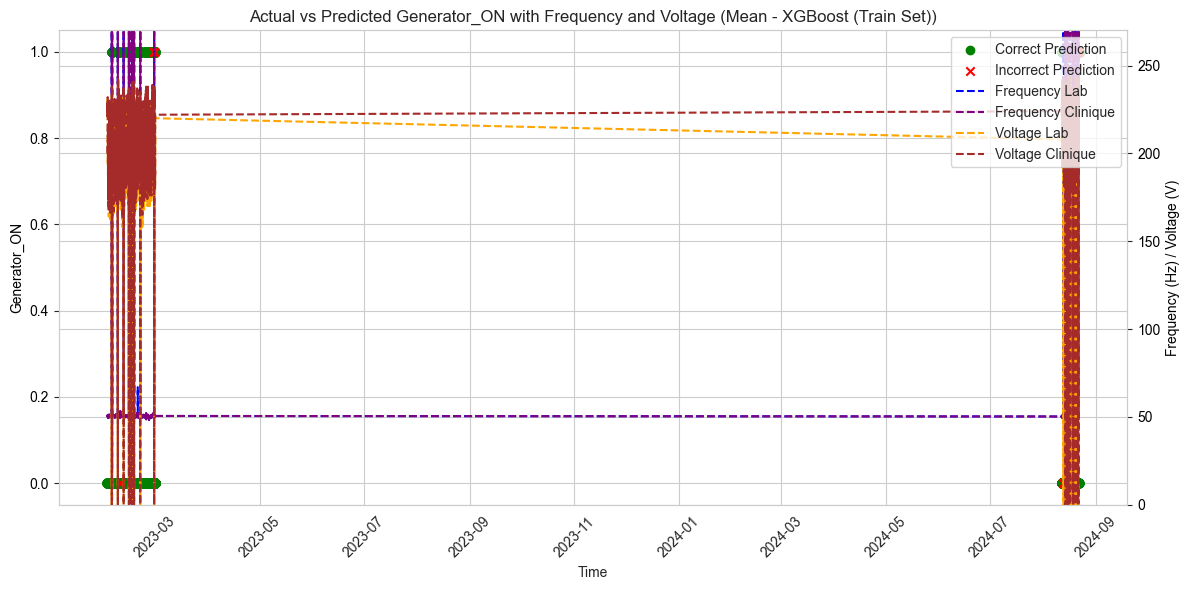

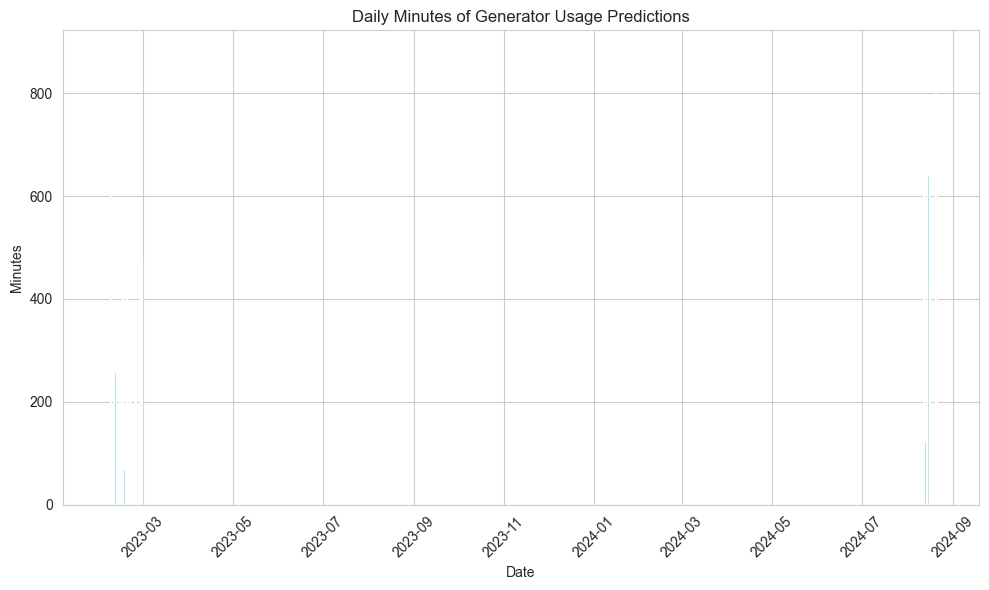

,Date,Count,Minutes,Hours
0,2023-02-03,75,150,2.500000
1,2023-02-07,352,704,11.733333
2,2023-02-08,1,2,0.033333
3,2023-02-10,129,258,4.300000
4,2023-02-13,145,290,4.833333
5,2023-02-15,210,420,7.000000
6,2023-02-16,35,70,1.166667
7,2023-02-18,221,442,7.366667
8,2023-02-20,194,388,6.466667
9,2023-02-23,191,382,6.366667


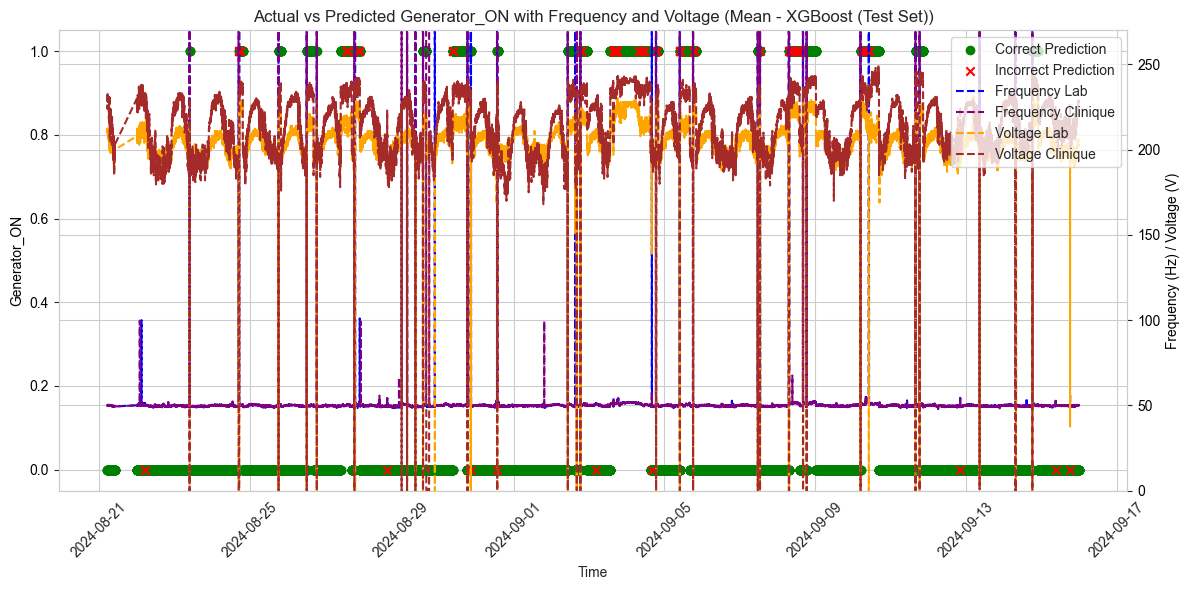

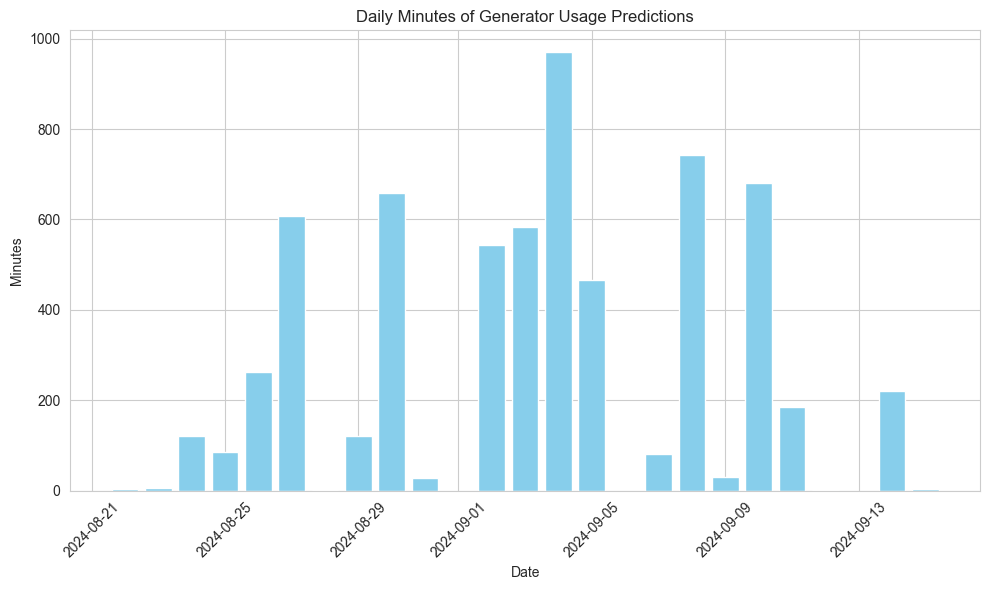

,Date,Count,Minutes,Hours
0,2024-08-22,2,4,0.066667
1,2024-08-23,3,6,0.100000
2,2024-08-24,60,120,2.000000
3,2024-08-25,43,86,1.433333
4,2024-08-26,131,262,4.366667
5,2024-08-27,304,608,10.133333
6,2024-08-28,1,2,0.033333
7,2024-08-29,60,120,2.000000
8,2024-08-30,329,658,10.966667
9,2024-08-31,14,28,0.466667


In [84]:
# For Boosting Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_co_boost, model_name="Mean - XGBoost (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
train_data_ts_co_boost_daily_count = plot_true_predictions_histogram(train_data_ts_co_boost)
display(train_data_ts_co_boost_daily_count)

# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_co_boost, model_name="Mean - XGBoost (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
test_data_ts_co_boost_daily_count = plot_true_predictions_histogram(test_data_ts_co_boost)
display(test_data_ts_co_boost_daily_count)

In [85]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_co_boost)
display_generator_statistics(test_data_ts_co_boost)

##### PREDICTION RESULT #####
Actual Minutes: 4005 minutes, or 66.75 hours within 453.60 hours
Predicted Minutes: 4028 minutes, or 67.13 hours within 453.60 hours
Actual Minutes: 3326 minutes, or 55.43 hours within 302.40 hours
Predicted Minutes: 3200 minutes, or 53.33 hours within 302.40 hours


## 5. Applying the Model with Other Data

Top 15 features sorted by importance:


,Feature,Importance
3,Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - cl...,0.419528
2,Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - la...,0.148025
0,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - ...,0.071939
1,Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - ...,0.070741
6,higher_volt_lab,0.046275
7,higher_volt_clinique,0.031487
31,Hour_11,0.018083
33,Hour_13,0.014285
34,Hour_14,0.013974
24,Hour_4,0.013622


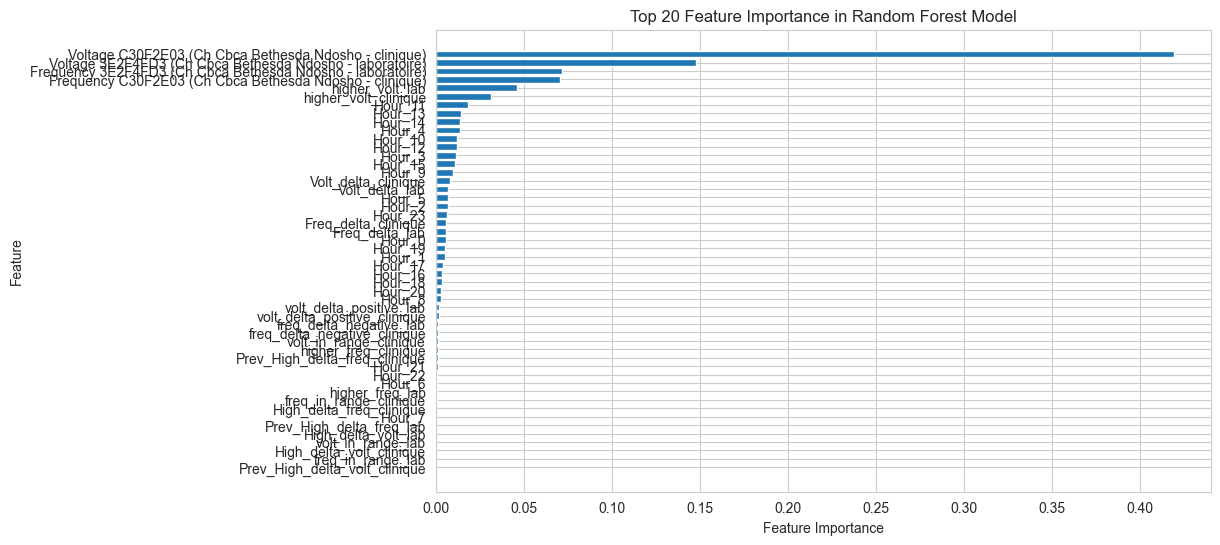

In [86]:
# Final Model use for prediction

# Step 1: Create copies of the original data
train_data_ts_rf = train_data_ts.copy()
test_data_ts_rf = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_rf, test_data_ts_rf = calculate_mean_flags(train_data_ts_rf, test_data_ts_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_rf[feature_columns]
y_train = train_data_ts_rf['Generator_ON']

X_test = test_data_ts_rf[feature_columns]
y_test = test_data_ts_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_rf['prediction'] = clf.predict(X_train)
test_data_ts_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(50)

# Display the top 15 most important features
print("Top 15 features sorted by importance:")
display(top_15_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(top_15_features['Feature'], top_15_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

#### 5.1. Using 1 Month Data and Check the Prediction Result

In [87]:
# Opening files
file_list = ['Voltage Time Series-data-2024-10-25 13_13_06.csv',  
             'Voltage Time Series-data-2024-10-25 13_13_40.csv', 
             'Voltage Time Series-data-2024-10-25 13_14_12.csv',
             'Voltage Time Series-data-2024-10-25 13_14_37.csv',
             'Voltage Time Series-data-2024-10-25 13_18_07.csv']

# Initialize an empty list to collect DataFrames
data_frames_2 = []

file_path_2 = 'data/0. ChCbNdosho/New 2/'

for file in file_list:
    # Read each file into a DataFrame and append to the list
    monthly_data = pd.read_csv(file_path_2 + file)
    data_frames_2.append(monthly_data)

# Concatenate all DataFrames in the list at once
data = pd.concat(data_frames_2, ignore_index=True)

# Display the final concatenated DataFrame
display(data)

,Time,Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique),Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire),Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)
0,2024-09-10 00:00:00,50.1,50.0,207.0,223.0
1,2024-09-10 00:02:00,49.8,49.8,203.0,221.0
2,2024-09-10 00:04:00,49.7,49.7,202.0,221.0
3,2024-09-10 00:06:00,49.8,49.8,204.0,221.0
4,2024-09-10 00:08:00,49.9,50.0,204.0,222.0
...,...,...,...,...,...
25195,2024-10-14 23:50:00,50.1,50.0,210.0,206.0
25196,2024-10-14 23:52:00,49.6,49.6,209.0,205.0
25197,2024-10-14 23:54:00,49.8,49.8,209.0,207.0
25198,2024-10-14 23:56:00,49.9,49.9,210.0,208.0


In [88]:
test_data_2

NameError: name 'test_data_2' is not defined

In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2, test_data_2_dummy = calculate_mean_flags(data, data, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2, test_data_2_dummy = process_time_series_data(test_data_2, test_data_2, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
test_data_2_daily_count = plot_true_predictions_histogram(test_data_2)
test_data_2_daily_count

#### 5.2. Using 1 Year Data of Year 2023

Loading 1 year data into 1 dataframe:

In [ ]:
# Set the path to the folder containing CSV files
folder_path = 'data/0. ChCbNdosho/2023 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2023 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2023['time'] = pd.to_datetime(data_2023['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2023 = data_2023.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2023

In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2023, test_data_2023_dummy = calculate_mean_flags(data_2023, data_2023, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2023, test_data_2023_dummy = process_time_series_data(test_data_2023, test_data_2023, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2023)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2023[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2023['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2023['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2023) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

##### 5.2.1. Plot Result During Lost Clinique Data (2023)

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2023, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
# Plot predictions based on certain timing choosen

start_date = '2023-12-01 00:00:00'
finished_date = '2023-12-31 23:59:59'
filtered_test_data_2023 = test_data_2023[(test_data_2023['Time'] >= start_date) & (test_data_2023['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2023,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2023)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2023['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2023) / 30
average_daily = filtered_test_data_2_daily_count['Minutes'].sum() / filtered_test_data_2_daily_count.shape[0] 
max_daily = filtered_test_data_2_daily_count['Minutes'].max()
# Find the row with the maximum 'Minutes' value
max_daily_row = filtered_test_data_2_daily_count.loc[filtered_test_data_2_daily_count['Minutes'].idxmax()]
# Extract the 'Date' column from that row
max_date = max_daily_row['Date']


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')
print(f'Average Daily Usage Minutes: {average_daily} minutes, or {average_daily / 60} hours')
print(f'Max minutes of usage {max_daily} minutes or {max_daily / 60} hours. Date: {max_date}')

##### 5.2.2. Plot Result First 10 days of July (2023)

In [ ]:
# Plot predictions based on certain timing choosen
start_date = '2023-02-14 00:00:00'
finished_date = '2023-02-17 23:59:59'
filtered_test_data_2023 = test_data_2023[(test_data_2023['Time'] >= start_date) & (test_data_2023['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2023,
    model_name=f"Mean - Random Forest for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)

# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2023)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2023['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2023) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

#### 5.3. Using Data of Year 2022

Due to data limitations, only Data from 27th May 2022 - 31st December 2022 is available

In [ ]:
# Loading the data

# Set the path to the folder containing CSV files
folder_path = 'data/0. ChCbNdosho/2022 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2022 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2022['time'] = pd.to_datetime(data_2022['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2022 = data_2022.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2022


In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2022, test_data_2022_dummy = calculate_mean_flags(data_2022, data_2022, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2022, test_data_2022_dummy = process_time_series_data(test_data_2022, test_data_2022, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2022)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2022[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2022['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2022['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2022) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

##### 5.2.2. Plot Result During Lost Clinique Data (2022)

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2022, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
# Plot predictions based on certain timing choosen

start_date = '2022-06-20 00:00:00'
finished_date = '2022-06-30 23:59:59'
filtered_test_data_2022 = test_data_2022[(test_data_2022['Time'] >= start_date) & (test_data_2022['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2022,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2022)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2022['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2022) / 30


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

display()

#### 5.4. Using Data of Year 2024

In [ ]:
# Loading the data

# Set the path to the folder containing CSV files
folder_path = 'data/0. ChCbNdosho/2024 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2024 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2024['time'] = pd.to_datetime(data_2024['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2024 = data_2024.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2024

In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2024, test_data_2024_dummy = calculate_mean_flags(data_2024, data_2024, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2024, test_data_2024_dummy = process_time_series_data(test_data_2024, test_data_2024, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2024)

# Define the feature columns
feature_columns = [
    freq_a,
    freq_b,
    volt_a,
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2024[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2024['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2024['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2024) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2024, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
# Plot predictions based on certain timing choosen

start_date = '2024-10-11 00:00:00'
finished_date = '2024-10-20 23:59:59'
filtered_test_data_2024 = test_data_2024[(test_data_2024['Time'] >= start_date) & (test_data_2024['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2024,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2024)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2024['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2024) / 30


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

display()

In [ ]:
## CHECK : 4-11 November

## 6. Summary of Data

#### 6.1. Generator 2022 Data

In [ ]:
year_summary, monthly_summary = generator_usage_summary(test_data_2022)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 6.2. Generator 2023 Data

In [ ]:
year_summary, monthly_summary = generator_usage_summary(test_data_2023)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 6.3. Generator 2024 Data

In [ ]:
year_summary, monthly_summary = generator_usage_summary(test_data_2024)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

## 7. Generator Power Calculation

In [ ]:
# Constant Declaration of Hourly kwh average
kwh_hour = [
    6.747835296, 7.057838155, 8.16854183, 11.30196556, 11.21547191, 9.88189269, 11.22740354, 12.85224141, 14.05086424, 13.96076821,
    13.70200973, 13.46483643, 13.25040271, 12.23739568, 9.853452467, 11.13546578, 11.58039839, 9.594331892, 9.649361468,
    8.320364238, 6.779637969, 6.241952539, 6.125157442, 6.18646468
]

#### 7.1. Generator 2022 Power

In [ ]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2022['power (kW)'] = test_data_2022.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2022[test_data_2022['prediction']]

In [ ]:
# Year 2022 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2022)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 7.2. Generator 2023 Power

In [ ]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2023['power (kW)'] = test_data_2023.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2023[test_data_2023['prediction']]

In [ ]:
# Year 2023 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2023)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 7.3. Generator 2024 Power

In [ ]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2024['power (kW)'] = test_data_2024.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2024[test_data_2024['prediction']]

In [ ]:
# Year 2024 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2024)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

## 8. Generator Emission Calculation

In [ ]:
# Constant Declaration of Emission index

#Assuming Un-Controlled NOx
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007

kwh_to_hp_hr = 1.341
lb_to_gr = 453.592

#### 8.1. Generator 2022 Emission

In [ ]:
test_data_2022 = calculate_emissions(test_data_2022)

test_data_2022[test_data_2022['prediction']]

In [ ]:
generator_emission_summary(test_data_2022)

#### 8.2. Generator 2023 Emission

In [ ]:
test_data_2023 = calculate_emissions(test_data_2023)

test_data_2023[test_data_2023['prediction']]

In [ ]:
generator_emission_summary(test_data_2023)

#### 8.3. Generator 2024 Emission

In [ ]:
test_data_2024 = calculate_emissions(test_data_2024)

test_data_2024[test_data_2024['prediction']]

In [ ]:
generator_emission_summary(test_data_2024)

## 9. Generator Output Emissions File

In [ ]:
file_name = ["data_2022.csv", "data_2023.csv", "data_2024.csv"]
years = [2022, 2023, 2024]
columns = ['Time','prediction','power (kW)','NOx Emission (g)','CO Emission (g)','SOx Emission (g)','CO2 Emission (g)','PM Emission (g)', 'Date', 'Month']

test_data_2024[columns].to_csv('results/data_2024.csv', index = False)
test_data_2023[columns].to_csv('results/data_2023.csv', index = False)
test_data_2022[columns].to_csv('results/data_2022.csv', index = False)